# Analyse et Prédiction des Montants Engagés
## M2 Économétrie et Statistiques (M2 ECAP) - Projet Machine Learning

**Auteur :** Florian Crochet  
**Date :** Février 2026  
**Cadre :** Compétition Machine Learning
**Enseignant :** Cédric Dangeard

---

## 1. 🎯 Contexte & Objectifs

Ce projet s'inscrit dans le cadre de l'évaluation finale du cours de **Machine Learning** (Compétition Kaggle). Il vise à développer un modèle prédictif robuste pour estimer le **montant des financements publics** (`montant_engage`) alloués à des projets de rénovation énergétique et de développement territorial.

**Objectifs Stratégiques :**
1.  **Performance** : Maximiser le score $R^2$ sur le test set.
2.  **Rigueur** : Approche "Data-Centric" reproductible et interprétable.

### 1.1. Données et Périmètre (Métadonnées)
*   **`train.csv`** : Apprentissage labellisé.
*   **`test.csv`** : Évaluation (Cible masquée).
*   **Variables** : Géographiques, Structurelles, Textuelles, Administratives.

### 1.2. Plan Méthodologique
Le notebook suit strictement le standard industriel défini dans le `README.md` :

1.  **Contexte & Objectifs** (Cette section)
2.  **Préparation des Données** (EDA, Pipeline, Feature Engineering)
3.  **Stratégie de Modélisation** (Validation, Modèles)
4.  **Résultats & Interprétabilité**
5.  **Pistes d'Amélioration**
6.  **Livrables**

---

In [1]:
# Gestion des données et Utilitaires
import os
import random
from itertools import product
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn : Preprocessing, Selection & Inspection
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer, TargetEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Modèles
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor, HistGradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

# Interprétabilité
import shap

# Configuration
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_columns', None)
import gensim.downloader as api

c:\Users\flori\Documents\Florian\21. University\1. Master\MASTER 2\Arbre de décision\dossier\master-year2-decision-trees\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Chargement des données
df_train = pd.read_csv('data/train.csv')

display(df_train.head(3))

,nom_du_projet,resume_du_projet,montant_engage,numero_ej,numero_operateur,opérateur,demarche,nom_region,nom_departement,code_departement,siret_beneficiaire,raison_sociale_beneficiaire,forme juridique_beneficiaire,code_commune,nom_commune,siret,activitePrincipale,codePostal,dateCreation,categorieEntreprise,trancheEffectifsUniteLegale,societeMissionUniteLegale,etatAdministratifEtablissement,anneeEffectifsEtablissement,economieSocialeSolidaireUniteLegale
0,"Changement des fenêtres ,des portes et pose de...","Suite aux différents audits, il convient de fi...",20710.00,2.104489e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Normandie,Eure,27,2.000561e+13,COMMUNE DE MARBOIS,Commune et commune nouvelle,27157,Marbois,2.000561e+13,84.11Z,27160.0,2016-01-01,PME,12,NaN,A,2023.0,N
1,ZAC Bernard Duval,La ZAC Claude Bernard / Alexandre Duval à Renn...,200000.00,2.104469e+09,NaN,NaN,Recyclage foncier,Bretagne,Ille-et-Vilaine,35,5.231896e+13,TERRITOIRES PUBLICS,SA à conseil d'administration (s.a.i.),35238,Rennes,5.231896e+13,42.99Z,35200.0,2010-05-10,ETI,03,NaN,A,2023.0,N
2,Travaux d'urgence de confortement et d'aménage...,Suites aux intempéries du début du mois de déc...,14157.02,2.104386e+09,NaN,NaN,Appui aux collectivités de montagne soumises à...,Provence-Alpes-Côte d'Azur,Hautes-Alpes,05,2.000673e+13,CC SERRE-PONCON VAL D'AVANCE,Communauté de communes,05017,La Bâtie-Neuve,2.000673e+13,84.11Z,5230.0,2017-01-01,PME,12,NaN,A,2023.0,N


## 2. 🛠️ Préparation des Données

L'approche privilégie une **architecture fonctionnelle modulaire** et stricte pour assurer la reproductibilité et éviter les fuites de données (data leakage) entre l'entraînement et l'inférence.


### 2.1. Exploration des Données (EDA)

> *"Une phase d'exploration est réalisée pour comprendre la structure des données brutes **avant transformation**."*

#### 2.1.1. Inspection Structurelle
*   **Dimensions** : Nombre d'observations et de variables.
*   **Types** : Identification des variables numériques, catégorielles et textuelles.
*   **Valeurs Manquantes** : Taux de remplissage par variable.

In [ ]:
# Inspection Structurelle
def inspect_data_structure(df, name="DataFrame"):
    print(f"\n--- Inspection Structurelle : {name} ---")
    print(f"  Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
    
    print(f"\n  [Types de Variables]")
    print(df.dtypes.value_counts())
    
    print(f"\n  [Taux de Remplissage (%)]")
    fill_rate = (1 - df.isnull().mean()).sort_values() * 100
    for col, rate in fill_rate.items():
        status = "✅" if rate == 100 else ("⚠️" if rate > 80 else "❌")
        print(f"  {status} {col:45s} : {rate:6.1f}%")

# Application sur le Train Set
inspect_data_structure(df_train, name="Jeu d'Entraînement")


--- Inspection Structurelle : Jeu d'Entraînement ---
  Dimensions : 7094 lignes × 25 colonnes

  [Types de Variables]
str        19
float64     6
Name: count, dtype: int64

  [Taux de Remplissage (%)]
  ❌ societeMissionUniteLegale                     :    0.2%
  ❌ opérateur                                     :   15.1%
  ❌ numero_operateur                              :   15.1%
  ❌ economieSocialeSolidaireUniteLegale           :   72.3%
  ⚠️ numero_ej                                     :   84.9%
  ⚠️ anneeEffectifsEtablissement                   :   94.4%
  ⚠️ etatAdministratifEtablissement                :   96.7%
  ⚠️ categorieEntreprise                           :   96.9%
  ⚠️ resume_du_projet                              :   97.5%
  ⚠️ codePostal                                    :   97.6%
  ⚠️ activitePrincipale                            :   97.7%
  ⚠️ dateCreation                                  :   97.7%
  ⚠️ nom_region                                    :   97.7%
  ⚠️ sire

**Interprétation de l'Inspection Structurelle :**

1.  **Dimensions & Volume de Données :**
    Le jeu d'entraînement contient **7 094 observations**, ce qui est relativement modeste pour un problème de Machine Learning complexe. Le jeu de test (1 774 lignes) représente environ 20% du volume total, respectant un ratio classique (80/20). La dimensionnalité initiale est de 25 variables, suggérant un besoin de sélection rigoureuse pour éviter le sur-apprentissage, surtout avec des modèles d'arbres.

2.  **Typologie des Variables :**
    La majorité des variables sont de type **object (string)** (19 sur 25), indiquant une prépondérance de données catégorielles (codes administratifs, noms de lieux) et textuelles (descriptions). Seules 6 variables sont nativement numériques (`float64`), ce qui confirme l'importance cruciale de la phase de **Feature Engineering** (Encodage, NLP) pour rendre ces données exploitables par les algorithmes.

3.  **Qualité des Données (Valeurs Manquantes) :**
    L'analyse des taux de remplissage révèle des disparités marquées :
    *   **Variables Critiques (100%) :** Le `nom_du_projet` et surtout la cible `montant_engage` sont complets, ce qui est une excellente base.
    *   **Variables Structurelles (>95%) :** Les identifiants géographiques (`commune`, `region`) et administratifs (`siret`, `activitePrincipale`) sont très bien renseignés, permettant des jointures et segmentations fiables.
    *   **Variables Lacunaires (<20%) :** `societeMissionUniteLegale` (0.2%) ou `opérateur` (15.1%) présentent des taux de vide massifs. Pour ces variables, l'absence d'information (NA) devra être traitée comme une modalité informative ("Non renseigné" ou "Non concerné") plutôt que par une imputation statistique standard (moyenne/médiane), qui introduirait un biais trop fort.


#### 2.1.2. Analyse Univariée
*   **Variable Cible (`montant_engage`)** : Distribution, asymétrie (skewness), présence de valeurs extrêmes.
*   **Variables Catégorielles** : Fréquences, cardinalité, modalités rares.
*   **Variables Numériques** : Statistiques descriptives, histogrammes.


--- Analyse Univariée (Cible : montant_engage) ---
  Count:    7094
  Mean:     181,802.36
  Median:   63,241.40
  Std:      377,617.46
  Min:      287.50
  Max:      11,600,000.00
  Skewness: 10.46
  Kurtosis: 214.31


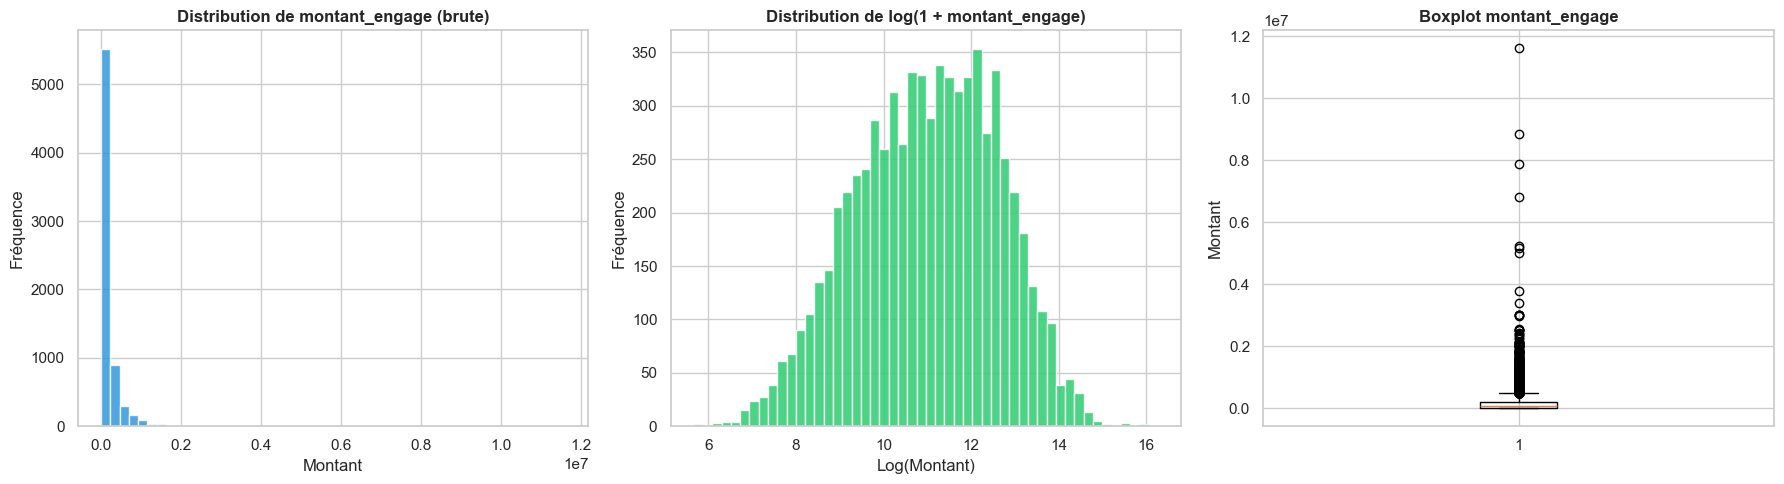


--- Cardinalité des Variables ---
  nom_du_projet                                 :   6697 uniques  (str)
  resume_du_projet                              :   6789 uniques  (str)
  montant_engage                                :   5766 uniques  (float64)
  numero_ej                                     :   6018 uniques  (float64)
  numero_operateur                              :   1072 uniques  (str)
  opérateur                                     :      7 uniques  (str)
  demarche                                      :     17 uniques  (str)
  nom_region                                    :     23 uniques  (str)
  nom_departement                               :    106 uniques  (str)
  code_departement                              :    106 uniques  (str)
  siret_beneficiaire                            :   5238 uniques  (float64)
  raison_sociale_beneficiaire                   :   5139 uniques  (str)
  forme juridique_beneficiaire                  :     61 uniques  (str)
  code_commune   

In [ ]:
# Analyse Univariée
def analyze_univariate(df, target_col='montant_engage'):
    print(f"\n--- Analyse Univariée (Cible : {target_col}) ---")
    if target_col in df.columns:
        target = df[target_col]
        print(f"  Count:    {target.count()}")
        print(f"  Mean:     {target.mean():,.2f}")
        print(f"  Median:   {target.median():,.2f}")
        print(f"  Std:      {target.std():,.2f}")
        print(f"  Min:      {target.min():,.2f}")
        print(f"  Max:      {target.max():,.2f}")
        print(f"  Skewness: {target.skew():.2f}")
        print(f"  Kurtosis: {target.kurtosis():.2f}")

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Distribution brute
        axes[0].hist(target, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
        axes[0].set_title(f'Distribution de {target_col} (brute)', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Montant')
        axes[0].set_ylabel('Fréquence')

        # Distribution log
        # Gestion des valeurs négatives pour le log (log1p ne gère pas < -1)
        # Ici on suppose montant >= 0 ou on filtre pour le graph
        valid_log = target[target > 0]
        if len(valid_log) > 0:
            axes[1].hist(np.log1p(valid_log), bins=50, color='#2ecc71', edgecolor='white', alpha=0.85)
            axes[1].set_title(f'Distribution de log(1 + {target_col})', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Log(Montant)')
            axes[1].set_ylabel('Fréquence')
        else:
            axes[1].text(0.5, 0.5, "Pas de valeurs > 0 pour Log", ha='center')

        # Boxplot
        axes[2].boxplot(target, vert=True)
        axes[2].set_title(f'Boxplot {target_col}', fontsize=12, fontweight='bold')
        axes[2].set_ylabel('Montant')

        plt.tight_layout()
        plt.show()
    else:
        print(f"La colonne cible '{target_col}' est absente du DataFrame.")

    # Cardinalité des variables catégorielles
    print(f"\n--- Cardinalité des Variables ---")
    for col in df.columns:
        nunique = df[col].nunique()
        dtype = str(df[col].dtype)
        print(f"  {col:45s} : {nunique:6d} uniques  ({dtype})")

    # Statistiques descriptives numériques
    print(f"\n--- Statistiques Descriptives (Numériques) ---")
    print(df.describe().round(2).to_string())

# Application sur le Train Set (inclut le target pour l'analyse)
analyze_univariate(df_train, target_col='montant_engage')

**Interprétation de l'Analyse Univariée :**

1.  **Variable Cible (`montant_engage`) : Une Asymétrie Majeure**
    *   **Statistiques :** La distribution est extrêmement étalée vers la droite (*Skewness* = 10.46, *Kurtosis* = 214.31). La moyenne (181 k€) est près de **3 fois supérieure** à la médiane (63 k€), tirée par des valeurs extrêmes atteignant 11.6 M€.
    *   **Graphiques :** L'histogramme brut est illisible (barre unique à gauche), confirmant la nécessité absolue d'une transformation. L'histogramme **Log(1 + Montant)** (au centre) rétablit une forme en cloche quasi-normale, validant la pertinence de la `TransformedTargetRegressor` avec `func=np.log1p` pour la modélisation.
    *   **Valeurs Extrêmes :** Le Boxplot montre une "pluie" d'outliers au-delà de la moustache supérieure. Ces projets à très gros budget sont des **événements rares mais légitimes** (ex: rénovation complexe) qu'il faut conserver et modéliser, et non supprimer.

2.  **Variables Catégorielles : Le Défi de la Cardinalité**
    *   **Haute Cardinalité (High-Card) :** `nom_du_projet` (~6700), `resume_du_projet` (~6800), `siret` (~5200) et `code_commune` (~4500) ont presque autant de modalités que de lignes.
        *   *Implication :* Le One-Hot Encoding est impossible ici (explosion dimensionnelle). L'approche par **Target Encoding** (pour les lieux/sirets) et **TF-IDF/Embeddings** (pour le texte) définie en §2.2.5 est donc techniquement justifiée.
    *   **Cardinalité Modérée :** `activitePrincipale` (146), `departement` (106).
    *   **Faible Cardinalité (Low-Card) :** `region` (23), `demarche` (17), `opérateur` (7). Le One-Hot Encoding standard suffira.

3.  **Variables Numériques & Atypiques :**
    *   `anneeEffectifsEtablissement` a un écart-type de 0 (toutes valeurs = 2023). **Variable constante** à supprimer (confirmé par §2.2.2).
    *   `codePostal` et `siret` sont traités comme des nombres (moyenne/std affichées) mais sont conceptuellement des catégories. Il faudra les convertir ou les exclure des statistiques numériques pures.


### 2.2. Pipeline de Traitement

*   **Principe Fondamental** : Séparation stricte `fit` (sur Train uniquement) vs `transform` (Train & Test).
*   **Structure Modulaire** :
    1.  **Cleaner** (Action Lignes/Colonnes) : `RenommeurVariables` -> `SelecteurVariables` -> `Dedupliqueur` -> `FiltreValeursAberrantes`.
    2.  **Transformer** (Action Valeurs/Types) : `ColumnTransformer` encapsulant des classes `BaseEstimator`, `TransformerMixin`.
*   **Méthodologie Propre** :
    *   **Périmètre d'Analyse** : Calibré exclusivement sur `data/train.csv`.
    *   **Modularité** : Distinction code nettoyage (suppression lignes) vs transformation (colonnes).
    *   **Standards Scikit-Learn** : Les classes Transformers héritent de `sklearn.base.BaseEstimator` et `sklearn.base.TransformerMixin` (pour compatibilité Pipeline).

#### 2.2.1. Normalisation du Schéma de Données

| Nom Original (train.csv / info) | Nouveau Nom (`snake_case`) | Signification / Justification |
| :--- | :--- | :--- |
| `Nom du projet` | `nom_projet` | Identifiant textuel court. |
| `Resume du projet` | `resume_projet` | Description textuelle longue. |
| `montant_engage` | `montant_engage` | **Variable Cible**. |
| `Nom Region` | `region_nom` | Nom de la région administrative. |
| `Nom Departement` | `departement_nom` | Informations redondantes (à supprimer). |
| `Code Departement` | `departement_code` | Code INSEE département. |
| `Code Commune` | `commune_code` | Code INSEE commune (Clé de jointure géo). |
| `Nom Commune` | `commune_nom` | Informations redondantes (à supprimer). |
| `Operateur` | `operateur_nom` | Organisme gestionnaire de l'aide. |
| `Demarche` | `demarche_nom` | Nom du dispositif administratif. |
| `Date Creation` | `date_creation` | Date de création de l'entreprise demandeur. |
| `Activite Principale` | `activite_principale_code` | Code NAF (APE) de l'activité principale. |
| `CategorieEntreprise` | `categorie_entreprise` | Taille catégorielle (PME, ETI, GE). |
| `CategorieJuridiqueUniteLegale` | `categorie_juridique_code` | Forme juridique détaillée. |
| `trancheEffectifsUniteLegale` | `tranche_effectifs` | Tranche de salariés déclarée. |
| `SocieteMissionUniteLegale` | `societe_mission` | Indicateur "Société à Mission" (Oui/Non). |
| `EconomieSocialeSolidaire...` | `eco_sociale_solidaire` | Indicateur ESS (Oui/Non). |
| `EtatAdministratifEtablissement`| `etat_administratif` | État de l'établissement (Actif/Fermé) - Quasi constant. |
| `Numero EJ` | `numero_ej` | Identifiant technique (à supprimer). |
| `numero operateur` | `numero_operateur` | Identifiant technique (à supprimer). |
| `AnneeEffectifsEtablissement` | `annee_effectifs` | Métadonnée technique (à supprimer). |
| `NomenclatureActivite...` | `activite_nomenclature` | Métadonnée technique (à supprimer). |

In [ ]:
class RenommageVariables(BaseEstimator, TransformerMixin):
    """
    Renomme les colonnes selon un dictionnaire de mapping fourni.
    """
    
    def __init__(self, mapping_dict):
        self.mapping_dict = mapping_dict

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        # On applique le renommage sur une copie pour ne pas modifier l'original
        return X.rename(columns=self.mapping_dict)

In [ ]:
column_mapping = {
    # Correspondance précise basée sur les headers du fichier CSV
    'nom_du_projet': 'nom_projet',
    'resume_du_projet': 'resume_projet',
    'montant_engage': 'montant_engage',
    'nom_region': 'region_nom',
    'nom_departement': 'departement_nom',
    'code_departement': 'departement_code',
    'code_commune': 'commune_code',
    'nom_commune': 'commune_nom',
    'opérateur': 'operateur_nom', 
    'demarche': 'demarche_nom',
    'dateCreation': 'date_creation',
    'activitePrincipale': 'activite_principale_code',
    'categorieEntreprise': 'categorie_entreprise',
    'forme juridique_beneficiaire': 'categorie_juridique_code',
    'trancheEffectifsUniteLegale': 'tranche_effectifs',
    'societeMissionUniteLegale': 'societe_mission',
    'economieSocialeSolidaireUniteLegale': 'eco_sociale_solidaire', 
    'etatAdministratifEtablissement': 'etat_administratif',
    'numero_ej': 'numero_ej',
    'numero_operateur': 'numero_operateur',
    'anneeEffectifsEtablissement': 'annee_effectifs',
    'NomenclatureActivitePrincipaleUniteLegale': 'activite_nomenclature',
}

# Instanciation du Renommage
renommage = RenommageVariables(column_mapping)

# Vérification sur df_train
display(renommage.transform(df_train).head())

,nom_projet,resume_projet,montant_engage,numero_ej,numero_operateur,operateur_nom,demarche_nom,region_nom,departement_nom,departement_code,siret_beneficiaire,raison_sociale_beneficiaire,categorie_juridique_code,commune_code,commune_nom,siret,activite_principale_code,codePostal,date_creation,categorie_entreprise,tranche_effectifs,societe_mission,etat_administratif,annee_effectifs,eco_sociale_solidaire
0,"Changement des fenêtres ,des portes et pose de...","Suite aux différents audits, il convient de fi...",20710.00,2.104489e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Normandie,Eure,27,2.000561e+13,COMMUNE DE MARBOIS,Commune et commune nouvelle,27157,Marbois,2.000561e+13,84.11Z,27160.0,2016-01-01,PME,12,NaN,A,2023.0,N
1,ZAC Bernard Duval,La ZAC Claude Bernard / Alexandre Duval à Renn...,200000.00,2.104469e+09,NaN,NaN,Recyclage foncier,Bretagne,Ille-et-Vilaine,35,5.231896e+13,TERRITOIRES PUBLICS,SA à conseil d'administration (s.a.i.),35238,Rennes,5.231896e+13,42.99Z,35200.0,2010-05-10,ETI,03,NaN,A,2023.0,N
2,Travaux d'urgence de confortement et d'aménage...,Suites aux intempéries du début du mois de déc...,14157.02,2.104386e+09,NaN,NaN,Appui aux collectivités de montagne soumises à...,Provence-Alpes-Côte d'Azur,Hautes-Alpes,05,2.000673e+13,CC SERRE-PONCON VAL D'AVANCE,Communauté de communes,05017,La Bâtie-Neuve,2.000673e+13,84.11Z,5230.0,2017-01-01,PME,12,NaN,A,2023.0,N
3,Rénovation thermique de l'école de GERBEPAL - ...,La commune de GERBÉPAL souhaite rénover le bât...,202019.00,2.104371e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Grand Est,Vosges,88,2.188020e+13,COMMUNE DE GERBEPAL,Commune et commune nouvelle,88198,Gerbépal,2.188020e+13,84.11Z,88430.0,1999-12-25,PME,11,NaN,A,2023.0,N
4,Rénovation énergétique du Centre Omnisport de ...,Situé à proximité du quartier de Marbé au nord...,587251.00,2.104409e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Bourgogne-Franche-Comté,Saône-et-Loire,71,2.171027e+13,COMMUNE DE MACON,Commune et commune nouvelle,71270,Mâcon,2.171027e+13,84.11Z,71000.0,1983-03-01,ETI,42,NaN,A,2023.0,N


#### 2.2.2. Filtrage des Variables (Pertinence Économique)
*   **Suppressions** :
    *   **Identifiants** : `numero_ej`, `numero_operateur`, `siret`, `siret_beneficiaire`, `raison_sociale_beneficiaire` (cardinalité extrême, sur-apprentissage).
    *   **Redondances** : `commune_nom`, `departement_nom`, `forme_juridique_beneficiaire`, `code_postal` (vs `commune_code`).
    *   **Constantes/Tech** : `annee_effectifs`, `activite_nomenclature`, `etat_administratif`.
*   **Traitement Manquants (SmartImputer)** :
    *   Utiliser le manquant comme modalité informative (ex: absence code commune = projet supra-communal).
    *   **VarianceThreshold** : Suppression automatique des variables à variance nulle.

In [ ]:
class SelecteurVariables(BaseEstimator, TransformerMixin):
    """
    Sélectionne les colonnes à conserver et supprime les autres.
    Gère suppression des IDs et colonnes techniques.
    """
    
    def __init__(self, drop_columns):
        self.drop_columns = drop_columns

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        # Suppression des colonnes indésirables présentes dans le DataFrame
        cols_to_drop = [c for c in self.drop_columns if c in X.columns]
        return X.drop(columns=cols_to_drop)

In [ ]:
# Filtrage des colonnes
drop_cols = [
    'numero_ej', 'numero_operateur', 'siret', 'siret_beneficiaire', 'raison_sociale_beneficiaire',
    'commune_nom', 'departement_nom', 'forme_juridique_beneficiaire', 'code_postal',
    'annee_effectifs', 'activite_nomenclature', 'etat_administratif'
]

# Instanciation du Selecteur
selecteur = SelecteurVariables(drop_columns=drop_cols)

# Vérification sur df_train
# Note: On applique d'abord 'renommage' car le sélecteur attend les noms de colonnes standardisés.
display(selecteur.transform(renommage.transform(df_train)).head())

,nom_projet,resume_projet,montant_engage,operateur_nom,demarche_nom,region_nom,departement_code,categorie_juridique_code,commune_code,activite_principale_code,codePostal,date_creation,categorie_entreprise,tranche_effectifs,societe_mission,eco_sociale_solidaire
0,"Changement des fenêtres ,des portes et pose de...","Suite aux différents audits, il convient de fi...",20710.00,NaN,Rénovation énergétique des bâtiments publics l...,Normandie,27,Commune et commune nouvelle,27157,84.11Z,27160.0,2016-01-01,PME,12,NaN,N
1,ZAC Bernard Duval,La ZAC Claude Bernard / Alexandre Duval à Renn...,200000.00,NaN,Recyclage foncier,Bretagne,35,SA à conseil d'administration (s.a.i.),35238,42.99Z,35200.0,2010-05-10,ETI,03,NaN,N
2,Travaux d'urgence de confortement et d'aménage...,Suites aux intempéries du début du mois de déc...,14157.02,NaN,Appui aux collectivités de montagne soumises à...,Provence-Alpes-Côte d'Azur,05,Communauté de communes,05017,84.11Z,5230.0,2017-01-01,PME,12,NaN,N
3,Rénovation thermique de l'école de GERBEPAL - ...,La commune de GERBÉPAL souhaite rénover le bât...,202019.00,NaN,Rénovation énergétique des bâtiments publics l...,Grand Est,88,Commune et commune nouvelle,88198,84.11Z,88430.0,1999-12-25,PME,11,NaN,N
4,Rénovation énergétique du Centre Omnisport de ...,Situé à proximité du quartier de Marbé au nord...,587251.00,NaN,Rénovation énergétique des bâtiments publics l...,Bourgogne-Franche-Comté,71,Commune et commune nouvelle,71270,84.11Z,71000.0,1983-03-01,ETI,42,NaN,N


#### 2.2.3. Déduplication
*   **Action** : Suppression stricte des lignes parfaitement identiques (doublons complets).
*   **Justification** : Évite le biais de pondération et surtout la **fuite de données** (si un doublon se retrouve à la fois dans le train et le test set).

In [ ]:
class Dedupliqueur(BaseEstimator, TransformerMixin):
    """
    Suppression stricte des doublons complets (Lignes) en mode Train uniquement.
    """
    def __init__(self, is_train=True):
        self.is_train = is_train
    
    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def transform(self, X):
        X_clean = X.copy()
        n_dupes = X_clean.duplicated().sum()
        
        if n_dupes > 0:
            print(f"  [Dedupliqueur] {n_dupes} doublons complets identifiés.")
            if self.is_train:
                print(f"    -> Suppression (Mode Train).")
                return X_clean.drop_duplicates()
            else:
                print(f"    -> Conservation (Mode Test/Validation).")
                return X_clean
        else:
            print(f"  [Dedupliqueur] Aucun doublon détecté.")
            return X_clean


# Instanciation du Dedupliqueur
deduper = Dedupliqueur()

# Vérification sur df_train
display(deduper.transform(df_train).head())


  [Dedupliqueur] Aucun doublon détecté.


,nom_du_projet,resume_du_projet,montant_engage,numero_ej,numero_operateur,opérateur,demarche,nom_region,nom_departement,code_departement,siret_beneficiaire,raison_sociale_beneficiaire,forme juridique_beneficiaire,code_commune,nom_commune,siret,activitePrincipale,codePostal,dateCreation,categorieEntreprise,trancheEffectifsUniteLegale,societeMissionUniteLegale,etatAdministratifEtablissement,anneeEffectifsEtablissement,economieSocialeSolidaireUniteLegale
0,"Changement des fenêtres ,des portes et pose de...","Suite aux différents audits, il convient de fi...",20710.00,2.104489e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Normandie,Eure,27,2.000561e+13,COMMUNE DE MARBOIS,Commune et commune nouvelle,27157,Marbois,2.000561e+13,84.11Z,27160.0,2016-01-01,PME,12,NaN,A,2023.0,N
1,ZAC Bernard Duval,La ZAC Claude Bernard / Alexandre Duval à Renn...,200000.00,2.104469e+09,NaN,NaN,Recyclage foncier,Bretagne,Ille-et-Vilaine,35,5.231896e+13,TERRITOIRES PUBLICS,SA à conseil d'administration (s.a.i.),35238,Rennes,5.231896e+13,42.99Z,35200.0,2010-05-10,ETI,03,NaN,A,2023.0,N
2,Travaux d'urgence de confortement et d'aménage...,Suites aux intempéries du début du mois de déc...,14157.02,2.104386e+09,NaN,NaN,Appui aux collectivités de montagne soumises à...,Provence-Alpes-Côte d'Azur,Hautes-Alpes,05,2.000673e+13,CC SERRE-PONCON VAL D'AVANCE,Communauté de communes,05017,La Bâtie-Neuve,2.000673e+13,84.11Z,5230.0,2017-01-01,PME,12,NaN,A,2023.0,N
3,Rénovation thermique de l'école de GERBEPAL - ...,La commune de GERBÉPAL souhaite rénover le bât...,202019.00,2.104371e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Grand Est,Vosges,88,2.188020e+13,COMMUNE DE GERBEPAL,Commune et commune nouvelle,88198,Gerbépal,2.188020e+13,84.11Z,88430.0,1999-12-25,PME,11,NaN,A,2023.0,N
4,Rénovation énergétique du Centre Omnisport de ...,Situé à proximité du quartier de Marbé au nord...,587251.00,2.104409e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Bourgogne-Franche-Comté,Saône-et-Loire,71,2.171027e+13,COMMUNE DE MACON,Commune et commune nouvelle,71270,Mâcon,2.171027e+13,84.11Z,71000.0,1983-03-01,ETI,42,NaN,A,2023.0,N


#### 2.2.4. Traitement des Valeurs Extrêmes : Aberrations vs Atypiques

Une distinction stricte est faite entre **Erreur** et **Information** :

*   **1. Valeurs Aberrantes (Erreurs) :**
    *   *Définition :* Données impossibles ou incohérentes (ex: date future, montant < 0).
    *   *Action :* **Suppression stricte** des lignes concernées.
    *   *Protocole* : 12 vérifications exhaustives basées sur les règles métier.

*   **2. Valeurs Atypiques (Extrêmes) :**
    *   *Définition :* Données réelles mais rares (ex: Montant très élevé).
    *   *Action :* **Conservation intégrale**.
    *   *Traitement :* Gérées par la transformation **Box-Cox** (stabilisation variance) et la robustesse des modèles d'Arbres.


In [ ]:
class NettoyeurAberrations(BaseEstimator, TransformerMixin):
    """
    Suppression (Train) ou Signalement (Test) des valeurs aberrantes selon 12 règles métier.
    """
    
    def __init__(self, is_train=True):
        self.is_train = is_train

    def fit(self, X, y=None):
        self.fitted_ = True
        return self

    def detect_aberrant_values(self, df):
        from datetime import datetime
        aberrant_masks = {}
        
        # --- 1. montant_engage < 0 ---
        if 'montant_engage' in df.columns:
            mask = df['montant_engage'] < 0
            if mask.any():
                aberrant_masks['montant_engage < 0'] = mask
        
        # --- 2 & 3. dateCreation ---
        if 'dateCreation' in df.columns:
            dates = pd.to_datetime(df['dateCreation'], errors='coerce')
            mask_future = dates > pd.Timestamp.now()
            if mask_future.any():
                aberrant_masks['dateCreation future'] = mask_future
            mask_invalid = df['dateCreation'].notna() & dates.isna()
            if mask_invalid.any():
                aberrant_masks['dateCreation format invalide'] = mask_invalid
                
        # --- 4 & 5. anneeEffectifsEtablissement ---
        col_annee = 'anneeEffectifsEtablissement'
        if col_annee in df.columns:
            annee_num = pd.to_numeric(df[col_annee], errors='coerce')
            annee_str = df[col_annee].astype(str).str.replace('.0', '', regex=False)
            mask_format = df[col_annee].notna() & (
                annee_num.isna() | (annee_str.str.len() != 4)
            )
            if mask_format.any():
                aberrant_masks[f'{col_annee} format invalide'] = mask_format
            current_year = datetime.now().year
            mask_future_year = df[col_annee].notna() & (annee_num > current_year)
            if mask_future_year.any():
                aberrant_masks[f'{col_annee} > {current_year}'] = mask_future_year

        # --- 6. categorieEntreprise ---
        col_cat = 'categorieEntreprise'
        if col_cat in df.columns:
            valid_cat = {'PME', 'ETI', 'GE'}
            mask = df[col_cat].notna() & ~df[col_cat].isin(valid_cat)
            if mask.any():
                aberrant_masks[f'{col_cat} hors nomenclature'] = mask

        # --- 7. trancheEffectifsUniteLegale ---
        col_te = 'trancheEffectifsUniteLegale'
        if col_te in df.columns:
            valid_te = {'NN', '00', '01', '02', '03', '11', '12', '21', '22',
                        '31', '32', '41', '42', '51', '52', '53'}
            te_str = df[col_te].astype(str).str.zfill(2)
            mask = df[col_te].notna() & ~te_str.isin(valid_te)
            if mask.any():
                aberrant_masks[f'{col_te} hors nomenclature'] = mask

        # --- 8. societeMissionUniteLegale ---
        col_sm = 'societeMissionUniteLegale'
        if col_sm in df.columns:
            valid_sm = {'O', 'N'}
            mask = df[col_sm].notna() & ~df[col_sm].isin(valid_sm)
            if mask.any():
                aberrant_masks[f'{col_sm} hors nomenclature'] = mask

        # --- 9. economieSocialeSolidaireUniteLegale ---
        col_ess = 'economieSocialeSolidaireUniteLegale'
        if col_ess in df.columns:
            valid_ess = {'O', 'N'}
            mask = df[col_ess].notna() & ~df[col_ess].isin(valid_ess)
            if mask.any():
                aberrant_masks[f'{col_ess} hors nomenclature'] = mask

        # --- 10. etatAdministratifEtablissement ---
        col_etat = 'etatAdministratifEtablissement'
        if col_etat in df.columns:
            valid_etat = {'A', 'F'}
            mask = df[col_etat].notna() & ~df[col_etat].isin(valid_etat)
            if mask.any():
                aberrant_masks[f'{col_etat} hors nomenclature'] = mask

        # --- 11. Activite Principale ---
        col_nom = 'NomenclatureActivitePrincipaleUniteLegale'
        col_nom_alt = 'activite_nomenclature'
        actual_col = col_nom if col_nom in df.columns else (col_nom_alt if col_nom_alt in df.columns else None)
        if actual_col:
            valid_nom = {'NAFRev2', 'NAFRev1', 'NAF1993', 'NAP'}
            mask = df[actual_col].notna() & ~df[actual_col].isin(valid_nom)
            if mask.any():
                aberrant_masks[f'{actual_col} hors nomenclature'] = mask

        # --- 12. Categorie Juridique ---
        col_jur = 'CategorieJuridiqueUniteLegale'
        col_jur_alt = 'categorie_juridique_code'
        actual_col = col_jur if col_jur in df.columns else (col_jur_alt if col_jur_alt in df.columns else None)
        if actual_col:
            # On ne vérifie la longueur que si ce sont des codes numériques (pour éviter de supprimer les labels)
            jur_values = df[actual_col].astype(str).str.replace('.0', '', regex=False)
            mask_numeric = jur_values.str.isnumeric()
            mask_len = df[actual_col].notna() & mask_numeric & (jur_values.str.len() != 4)
            if mask_len.any():
                aberrant_masks[f'{actual_col} longueur != 4'] = mask_len
                
        return aberrant_masks

    def transform(self, X):
        X_clean = X.copy()
        print(f"  [NettoyeurAberrations] Analyse (is_train={self.is_train})...")
        aberrant_masks = self.detect_aberrant_values(X_clean)
        
        if len(aberrant_masks) == 0:
            print(f" Aucune valeur aberrante détectée.")
            return X_clean
        
        combined_mask = pd.Series(False, index=X_clean.index)
        for check, mask in aberrant_masks.items():
            n = mask.sum()
            print(f"{check} : {n} ligne(s)")
            combined_mask = combined_mask | mask
            
        if self.is_train:
            n_tot = combined_mask.sum()
            print(f"    -> Suppression de {n_tot} lignes.")
            return X_clean[~combined_mask]
        
        print(f"    -> Conservation (Test mode).")
        return X_clean


# Instanciation du Nettoyeur d'Aberrations
cleaner = NettoyeurAberrations(is_train=True)

# Vérification sur df_train
display(cleaner.transform(df_train).head())

  [NettoyeurAberrations] Analyse (is_train=True)...
 Aucune valeur aberrante détectée.


,nom_du_projet,resume_du_projet,montant_engage,numero_ej,numero_operateur,opérateur,demarche,nom_region,nom_departement,code_departement,siret_beneficiaire,raison_sociale_beneficiaire,forme juridique_beneficiaire,code_commune,nom_commune,siret,activitePrincipale,codePostal,dateCreation,categorieEntreprise,trancheEffectifsUniteLegale,societeMissionUniteLegale,etatAdministratifEtablissement,anneeEffectifsEtablissement,economieSocialeSolidaireUniteLegale
0,"Changement des fenêtres ,des portes et pose de...","Suite aux différents audits, il convient de fi...",20710.00,2.104489e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Normandie,Eure,27,2.000561e+13,COMMUNE DE MARBOIS,Commune et commune nouvelle,27157,Marbois,2.000561e+13,84.11Z,27160.0,2016-01-01,PME,12,NaN,A,2023.0,N
1,ZAC Bernard Duval,La ZAC Claude Bernard / Alexandre Duval à Renn...,200000.00,2.104469e+09,NaN,NaN,Recyclage foncier,Bretagne,Ille-et-Vilaine,35,5.231896e+13,TERRITOIRES PUBLICS,SA à conseil d'administration (s.a.i.),35238,Rennes,5.231896e+13,42.99Z,35200.0,2010-05-10,ETI,03,NaN,A,2023.0,N
2,Travaux d'urgence de confortement et d'aménage...,Suites aux intempéries du début du mois de déc...,14157.02,2.104386e+09,NaN,NaN,Appui aux collectivités de montagne soumises à...,Provence-Alpes-Côte d'Azur,Hautes-Alpes,05,2.000673e+13,CC SERRE-PONCON VAL D'AVANCE,Communauté de communes,05017,La Bâtie-Neuve,2.000673e+13,84.11Z,5230.0,2017-01-01,PME,12,NaN,A,2023.0,N
3,Rénovation thermique de l'école de GERBEPAL - ...,La commune de GERBÉPAL souhaite rénover le bât...,202019.00,2.104371e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Grand Est,Vosges,88,2.188020e+13,COMMUNE DE GERBEPAL,Commune et commune nouvelle,88198,Gerbépal,2.188020e+13,84.11Z,88430.0,1999-12-25,PME,11,NaN,A,2023.0,N
4,Rénovation énergétique du Centre Omnisport de ...,Situé à proximité du quartier de Marbé au nord...,587251.00,2.104409e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Bourgogne-Franche-Comté,Saône-et-Loire,71,2.171027e+13,COMMUNE DE MACON,Commune et commune nouvelle,71270,Mâcon,2.171027e+13,84.11Z,71000.0,1983-03-01,ETI,42,NaN,A,2023.0,N


#### 2.2.5. Spécifications de Traitement par Variable (Feature Engineering)

Cette section implémente la stratégie de transformation via un **`ColumnTransformer`** global :

*   **Variables Catégorielles (Faible Cardinalité)** : `OneHotEncoder`
    *   *Variables concernées* : `region_nom`, `departement_code`, `categorie_juridique_code`, `operateur_nom`, `demarche_nom`, `axe_thematique`.
    *   *Justification* : Faible nombre de modalités (< 20-50), encodage binaire optimal pour les Arbres.

*   **Variables Catégorielles (Forte Cardinalité)** : `TargetEncoder`
    *   *Variables concernées* : `commune_code`, `activite_principale_code`.
    *   *Justification* : Capture la moyenne de la cible (`montant_engage`) par catégorie sans exploser la dimensionnalité (vs OneHot).

*   **Variables Ordinales** : `OrdinalEncoder`
    *   *Variables concernées* : `tranche_effectifs`, `categorie_entreprise`.
    *   *Justification* : La hiérarchie (PME < ETI < GE, 0 < 10...) est préservée par un encodage entier (0, 1, 2...).

*   **Variables Textuelles** :
    *   `nom_projet` : **TF-IDF (1-2 ngrams, max 100)** pour capturer les mots-clés spécifiques.
    *   `resume_projet` : **Embeddings (FastText)**.
        *   Utilisation de vecteurs pré-entraînés (`cc.fr.300.bin`) pour capturer le contexte sémantique global (synonymie).
        *   *Note technique* : Le code utilise une classe wrapper `FastTextEmbeddingTransformer`.

*   **Variables Binaires** : `SimpleImputer`
    *   *Variables concernées* : `eco_sociale_solidaire`, `societe_mission`.
    *   *Action* : Remplissage des valeurs manquantes par 0 (False).


In [ ]:
# --- TÉLÉCHARGEMENT DU MODÈLE FASTTEXT (FRANÇAIS) ---
# Ce bloc télécharge et décompresse le modèle cc.fr.300.bin (env. 4.5 Go compressé, 7 Go décomprimé).
# À n'exécuter que si le fichier est manquant.

import os
import requests
import gzip
import shutil

model_directory = 'data'
model_filename = os.path.join(model_directory, 'cc.fr.300.bin')
url = 'https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.fr.300.bin.gz'
compressed_path = model_filename + '.gz'

if not os.path.exists(model_directory):
    os.makedirs(model_directory)

if not os.path.exists(model_filename):
    print(f"Le fichier {model_filename} est manquant. Début du téléchargement (cela peut prendre du temps)... ")
    
    # Téléchargement par morceaux pour éviter de saturer la RAM
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        total_length = int(r.headers.get('content-length', 0))
        dl = 0
        with open(compressed_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    dl += len(chunk)
                    if dl % (1024 * 1024 * 100) == 0: # Log tous les 100 Mo
                        print(f"  Téléchargé : {dl / (1024*1024):.0f} / {total_length / (1024*1024):.0f} Mo")
    
    print("Téléchargement terminé. Décompression en cours...")
    with gzip.open(compressed_path, 'rb') as f_in:
        with open(model_filename, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    
    os.remove(compressed_path)
    print(f"Modèle prêt : {model_filename}")
else:
    print(f"Le modèle {model_filename} est déjà présent.")

Le modèle data\cc.fr.300.bin est déjà présent.


In [ ]:
class FastTextEmbeddingTransformer(BaseEstimator, TransformerMixin):
    """
    Transformateur pour générer des embeddings de documents via FastText (Gensim).
    Moyenne des vecteurs de mots pour le résumé du projet.
    """
    def __init__(self, model_path='data/cc.fr.300.bin', vector_size=300):
        self.model_path = model_path
        self.vector_size = vector_size
        self.model = None

    def fit(self, X, y=None):
        self.fitted_ = True
        try:
            # Tentative de chargement du modèle
            # Note: Si le fichier n'est pas présent, on passe en mode soft-fail (zéros)
            # pour ne pas bloquer l'exécution si l'utilisateur n'a pas téléchargé le modèle.
            from gensim.models.fasttext import load_facebook_vectors
            import os
            if os.path.exists(self.model_path):
                print(f"  [FastText] Chargement du modèle depuis {self.model_path}...")
                # Correction: Utilisation de load_facebook_vectors pour les fichiers .bin de Facebook
                self.model = load_facebook_vectors(self.model_path)
                print("  [FastText] Modèle chargé.")
            else:
                print(f"  [FastText] Fichier {self.model_path} introuvable. Embeddings désactivés (Zéros).")
        except Exception as e:
            print(f"  [FastText] Erreur de chargement: {e}")
        return self

    def transform(self, X):
        # S'assurer que X est itérable (Series ou liste)
        if hasattr(X, 'values'):
            X = X.values.ravel()
        return np.vstack([self._get_embedding(str(text)) for text in X])

    def _get_embedding(self, text):
        if self.model is None or not text:
            return np.zeros(self.vector_size)
        
        words = text.split()
        # Filtrage des mots présents dans le vocabulaire
        vectors = [self.model[w] for w in words if w in self.model]
        
        if vectors:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(self.vector_size)
    def get_feature_names_out(self, input_features=None):
        return [f"fasttext_{i}" for i in range(self.vector_size)]


class FeatureEngineeringManager:
    """
    Gestionnaire centralisé pour la construction du pipeline de Feature Engineering.
    """
    def __init__(self):
        pass

    def build_pipeline(self, X_train):
        """
        Construit le ColumnTransformer selon les specs de l'EDA (Section 2.2.5).
        """
        
        # 1. Variables Catégorielles (Faible Cardinalité) -> OneHot
        # < 20-50 modalités
        cat_low_card_cols = ['region_nom', 'departement_code', 'categorie_juridique_code', 
                             'operateur_nom', 'demarche_nom']
        
        # 2. Variables Catégorielles (Forte Cardinalité) -> TargetEncoder
        # Capture la moyenne de la cible
        cat_high_card_cols = ['commune_code', 'activite_principale_code']
        
        # 3. Variables Ordinales -> OrdinalEncoder
        # Préservation de la hiérarchie
        ordinal_cols = ['tranche_effectifs', 'categorie_entreprise']
        
        # 4. Variables Textuelles
        # - Nom projet -> TF-IDF (mots-clés)
        txt_tfidf_col = 'nom_projet'
        # - Résumé projet -> FastText (sémantique)
        txt_embed_col = 'resume_projet'
        
        # 5. Variables Binaires -> Imputation simple (0)
        binary_cols = []

        # Construction du ColumnTransformer
        # Note: TfidfVectorizer attend un array 1D, donc nous utilisons le nom de colonne directement
        # si possible, ou appliquons une transformation. ColumnTransformer supporte 'nom_col' 
        # pour extraire une Series si le reste est configuré correctement.
        
        preprocessor = ColumnTransformer(
            transformers=[
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_low_card_cols),
                ('target', TargetEncoder(target_type='continuous', smooth=True), cat_high_card_cols),
                ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
                ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=100), txt_tfidf_col),
                ('fasttext', FastTextEmbeddingTransformer(), txt_embed_col),
                ('binary', SimpleImputer(strategy='constant', fill_value=0), binary_cols)
            ],
            remainder='drop', # On ignore les colonnes non spécifiées (ex: IDs, dates brutes)
            verbose_feature_names_out=False
        )
        
        # 5. Pipeline Final avec VarianceThreshold (Méthodologie L66)
        # Supprime les variables à variance nulle (constantes)
        full_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('selector', VarianceThreshold(threshold=0))
        ])
        
        return full_pipeline

# --- VÉRIFICATIONS ---

# 1. Test FastTextEmbeddingTransformer
ft = FastTextEmbeddingTransformer()
ft.fit(None)
df_eda = renommage.transform(df_train)
# Test sur les premières lignes
print(f"[Check] FastText Embeddings shape (5 lignes) : {ft.transform(df_eda['resume_projet'].iloc[:5]).shape}")

# 2. Test FeatureEngineeringManager
print("\n[Check] Construction Pipeline FE...")
fe_manager = FeatureEngineeringManager()
fe_pipe = fe_manager.build_pipeline(df_train)
print("  -> Pipeline construit avec succès.")
display(fe_pipe)


  [FastText] Chargement du modèle depuis data/cc.fr.300.bin...
  [FastText] Modèle chargé.
[Check] FastText Embeddings shape (5 lignes) : (5, 300)

[Check] Construction Pipeline FE...
  -> Pipeline construit avec succès.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('selector', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('target', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

### 2.2.6. Architecture du Pipeline

Le processus de traitement est scindé en deux phases distinctes pour respecter les contraintes de structure (suppression de lignes) et faciliter la reproductibilité :

1. **Phase de Prétraitement (Data Cleaning)** :
    * **Action** : Application séquentielle de classes de nettoyage agissant sur la structure des données (Lignes/Colonnes).
    * **Composants** : `RenommeurVariables`, `SelecteurVariables`, `Dedupliqueur`, `NettoyeurAberrations`.
    * **Sortie** : Un DataFrame nettoyé (`df_train_cleaned`).

2. **Phase de Transformation (Feature Engineering Pipeline)** :
    * **Action** : Un **`ColumnTransformer`** global piloté par la classe `FeatureEngineeringManager`.
    * **Design** : 
        * **One-Hot Encoding** : Variables catégorielles à faible cardinalité.
        * **Target Encoding** : Variables catégorielles à forte cardinalité (`commune_code`, etc.).
        * **Ordinal Encoding** : Variables avec une hiérarchie intrinsèque (`tranche_effectifs`, etc.).
        * **TF-IDF** : Analyse textuelle sur le nom des projets.
        * **Gensim Embeddings** : Représentation sémantique des résumés de projets.
        * **Imputation constante** : Gestion des valeurs manquantes pour les variables binaires.
    * **Sortie** : Une matrice de caractéristiques prête pour le modèle.

In [ ]:
class DataOrchestrator:
    """
    Classe responsable de l'exécution séquentielle du pipeline complet :
    1. Nettoyage Structurel (Renommage, Sélection, Doublons, Aberrations)
    2. Feature Engineering (Encodage, Embeddings)
    """
    def __init__(self, target_col='montant_engage'):
        self.target_col = target_col
        self.fe_manager = FeatureEngineeringManager()
        self.fe_pipe = None

        # Définition du dictionnaire de renommage
        self.mapping_dict = {
            'nom_du_projet': 'nom_projet',
            'resume_du_projet': 'resume_projet',
            'opérateur': 'operateur_nom',
            'demarche': 'demarche_nom',
            'nom_region': 'region_nom',
            'nom_departement': 'departement_nom',
            'code_departement': 'departement_code',
            'forme juridique_beneficiaire': 'categorie_juridique_code',
            'code_commune': 'commune_code',
            'nom_commune': 'commune_nom',
            'activitePrincipale': 'activite_principale_code',
            'codePostal': 'code_postal', 
            'dateCreation': 'date_creation',
            'trancheEffectifsUniteLegale': 'tranche_effectifs',
            'societeMissionUniteLegale': 'societe_mission',
            'etatAdministratifEtablissement': 'etat_administratif',
            'anneeEffectifsEtablissement': 'annee_effectifs',
            'economieSocialeSolidaireUniteLegale': 'eco_sociale_solidaire',
            'categorieEntreprise': 'categorie_entreprise',
        }
        
        # Colonnes à supprimer (redondantes ou techniques)
        self.drop_cols = ['numero_ej', 'numero_operateur', 'siret', 'siret_beneficiaire', 'raison_sociale_beneficiaire', 'commune_nom', 'departement_nom', 'code_postal', 'annee_effectifs', 'activite_nomenclature', 'etat_administratif']
        
        # Pipeline de nettoyage (structurel)
        self.cleaning_pipeline = Pipeline([
            ('renommage', RenommageVariables(mapping_dict=self.mapping_dict)),
            ('selector', SelecteurVariables(drop_columns=self.drop_cols)),
            ('dedup', Dedupliqueur()),
            ('outliers', NettoyeurAberrations())
        ])

    def _prepare_data_structure(self, df, is_train=True):
        """
        Privé : Applique le nettoyage structurel (renommage, sélection, doublons, outliers).
        """
        print(f"  [Orchestrator] Nettoyage structurel (is_train={is_train})...")
        df_work = df.copy()
        
        # Propagation du flag is_train aux transformateurs sensibles
        if 'dedup' in self.cleaning_pipeline.named_steps:
            self.cleaning_pipeline.named_steps['dedup'].is_train = is_train
        if 'outliers' in self.cleaning_pipeline.named_steps:
            self.cleaning_pipeline.named_steps['outliers'].is_train = is_train
            
        if is_train:
            return self.cleaning_pipeline.fit_transform(df_work)
        return self.cleaning_pipeline.transform(df_work)

    def fit_transform(self, df_train):
        """
        Public : Applique TOUT le pipeline (Nettoyage + Feature Engineering) sur le Train.
        Apprend les paramètres et retourne un DataFrame consolidé (X + y).
        """
        print("--- Orchestration : Fit & Transform (Train) ---")
        
        # 1. Nettoyage Structurel
        df_clean = self._prepare_data_structure(df_train, is_train=True)
        
        # Séparation X, y
        if self.target_col not in df_clean.columns:
            raise ValueError(f"Cible '{self.target_col}' absente après nettoyage.")
        X_clean = df_clean.drop(columns=[self.target_col])
        y = df_clean[self.target_col]

        # 2. Feature Engineering
        print("  [Orchestrator] Construction et Fit du pipeline FE...")
        self.fe_pipe = self.fe_manager.build_pipeline(X_clean)
        X_proc = self.fe_pipe.fit_transform(X_clean, y)
        
        # 3. Formatage final en DataFrame
        cols = self.fe_pipe.get_feature_names_out()
        df_res = pd.DataFrame(X_proc, columns=cols, index=X_clean.index)
        df_res[self.target_col] = y.values
        
        print(f"✅ Transformation terminée : {df_res.shape}")
        return df_res

    def transform(self, df_input):
        """
        Public : Applique TOUT le pipeline sur un nouveau DataFrame (Test/Inférence).
        Utilise les paramètres appris lors du fit_transform.
        Retourne un DataFrame consolidé (X + y si y est présent).
        """
        if self.fe_pipe is None:
             raise RuntimeError("L'orchestrateur doit être entraîné (.fit_transform) avant de pouvoir transformer de nouvelles données.")
             
        print("--- Orchestration : Transform (Inférence/Test) ---")
        
        # 1. Nettoyage Structurel
        df_clean = self._prepare_data_structure(df_input, is_train=False)
        
        # Séparation X, y (y est optionnel en test)
        y = None
        if self.target_col in df_clean.columns:
            X_clean = df_clean.drop(columns=[self.target_col])
            y = df_clean[self.target_col]
        else:
            X_clean = df_clean

        # 2. Feature Engineering (Transform uniquement)
        print("  [Orchestrator] Application du pipeline FE...")
        X_proc = self.fe_pipe.transform(X_clean)
        
        # 3. Formatage final en DataFrame
        cols = self.fe_pipe.get_feature_names_out()
        df_res = pd.DataFrame(X_proc, columns=cols, index=X_clean.index)
        
        if y is not None:
            df_res[self.target_col] = y.values
            
        print(f"✅ Transformation terminée : {df_res.shape}")
        return df_res

# Instanciation globale
orchestrator = DataOrchestrator()


In [ ]:
# # --- EXÉCUTION DU PIPELINE COMPLET SUR LE JEU D'ENTRAÎNEMENT ---
# df_train_transformed_full = orchestrator.fit_transform(df_train)
# display(df_train_transformed_full.head())


In [ ]:
# # --- SAUVEGARDE DU JEU DE DONNÉES TRANSFORMÉ ---
# 
# os.makedirs('results', exist_ok=True)

# # Sauvegarde en CSV pour réutilisation future
# output_path = 'results/df_train_transformed_full.csv'
# df_train_transformed_full.to_csv(output_path, index=False)
# print(f"df_train_transformed_full sauvegardé dans '{output_path}'")

In [ ]:
# # --- CHARGEMENT DU JEU DE DONNÉES (OPTIONNEL) ---
# input_path = 'results/df_train_transformed_full.csv'

# # Chargement direct depuis le fichier sauvegardé
# df_train_transformed_full = pd.read_csv(input_path)
# print(f"Données chargées : {df_train_transformed_full.shape}")
# display(df_train_transformed_full.head())

Données chargées : (7093, 624)


,region_nom_Auvergne-Rhône-Alpes,region_nom_Bourgogne-Franche-Comté,region_nom_Bretagne,region_nom_Centre-Val de Loire,region_nom_Corse,region_nom_Grand Est,region_nom_Guadeloupe,region_nom_Guyane,region_nom_Hauts-de-France,region_nom_La Réunion,region_nom_Martinique,region_nom_Normandie,region_nom_Nouvelle-Aquitaine,region_nom_Nouvelle-Calédonie,region_nom_Occitanie,region_nom_Pays de la Loire,region_nom_Polynésie française,region_nom_Provence-Alpes-Côte d'Azur,region_nom_Saint-Barthélemy,region_nom_Saint-Martin,region_nom_Saint-Pierre-et-Miquelon,region_nom_Wallis-et-Futuna,region_nom_Île-de-France,region_nom_nan,departement_code_01,departement_code_02,departement_code_03,departement_code_04,departement_code_05,departement_code_06,departement_code_07,departement_code_08,departement_code_09,departement_code_10,departement_code_11,departement_code_12,departement_code_13,departement_code_14,departement_code_15,departement_code_16,departement_code_17,departement_code_18,departement_code_19,departement_code_21,departement_code_22,departement_code_23,departement_code_24,departement_code_25,departement_code_26,departement_code_27,departement_code_28,departement_code_29,departement_code_2A,departement_code_2B,departement_code_30,departement_code_31,departement_code_32,departement_code_33,departement_code_34,departement_code_35,departement_code_36,departement_code_37,departement_code_38,departement_code_39,departement_code_40,departement_code_41,departement_code_42,departement_code_43,departement_code_44,departement_code_45,departement_code_46,departement_code_47,departement_code_48,departement_code_49,departement_code_50,departement_code_51,departement_code_52,departement_code_53,departement_code_54,departement_code_55,departement_code_56,departement_code_57,departement_code_58,departement_code_59,departement_code_60,departement_code_61,departement_code_62,departement_code_63,departement_code_64,departement_code_65,departement_code_66,departement_code_67,departement_code_68,departement_code_69,departement_code_70,departement_code_71,departement_code_72,departement_code_73,departement_code_74,departement_code_75,departement_code_76,departement_code_77,departement_code_78,departement_code_79,departement_code_80,departement_code_81,departement_code_82,departement_code_83,departement_code_84,departement_code_85,departement_code_86,departement_code_87,departement_code_88,departement_code_89,departement_code_90,departement_code_91,departement_code_92,departement_code_93,departement_code_94,departement_code_95,departement_code_971,departement_code_972,departement_code_973,departement_code_974,departement_code_975,departement_code_977,departement_code_978,departement_code_986,departement_code_987,departement_code_988,departement_code_nan,categorie_juridique_code_(Autre) Collectivité territoriale,categorie_juridique_code_(Autre) Service déconcentré de l'État à compétence territoriale,categorie_juridique_code_(Autre) Établissement public administratif local,"categorie_juridique_code_Association de droit local (Bas-Rhin, Haut-Rhin et Moselle)",categorie_juridique_code_Association déclarée,"categorie_juridique_code_Association déclarée, reconnue d'utilité publique",categorie_juridique_code_Association syndicale autorisée,categorie_juridique_code_Autre SA coopérative à conseil d'administration,categorie_juridique_code_Autre SARL coopérative,categorie_juridique_code_Autre personne de droit privé inscrite au registre du commerce et des sociétés,categorie_juridique_code_Autre société civile,categorie_juridique_code_Autre établissement public national administratif à compétence territoriale limitée,categorie_juridique_code_Autre établissement public national d'enseignement,categorie_juridique_code_Centre Intercommunal d'action sociale (CIAS),categorie_juridique_code_Centre communal d'action sociale,categorie_juridique_code_Collectivité et territoire d'Outre Mer,categorie_juridique_code_Communauté d'agglomération,categorie_juridique_code_Communauté d

#### Justification de la Suppression des Variables

Conformément à la méthodologie établie, le pipeline de nettoyage structurel (`DataOrchestrator`) procède à un élagage scientifique des données pour améliorer la généralisation des modèles et éviter le sur-apprentissage (*overfitting*).

**Variables supprimées et motifs :**

1.  **Identifiants & Noms Redondants** : 
    *   `numero_ej`, `numero_operateur`, `siret` : Ces identifiants administratifs n'ont pas de lien causal avec le montant engagé.
    *   `commune_nom`, `departement_nom` : Informations redondantes avec les codes INSEE (`commune_code`, `departement_code`) qui sont plus fiables pour l'encodage.
2.  **Risque de Sur-Apprentissage** : 
    *   `siret_beneficiaire`, `raison_sociale_beneficiaire` : Leur cardinalité est trop élevée (presque un nom unique par projet), ce qui inciterait le modèle à "apprendre par cœur" les noms des bénéficiaires plutôt que des tendances réelles.
3.  **Variables à Faible Information** : 
    *   `code_postal` : Moins précis que le code commune pour capturer les spécificités locales.
    *   `annee_effectifs`, `activite_nomenclature` : Quasi-constantes ou métadonnées techniques sans valeur prédictive.
    *   `etat_administratif` : Quasi-constante (99% d'établissements actifs), n'apportant aucune variance utile au modèle.

Cette étape garantit que seules les caractéristiques ayant un potentiel explicatif réel sont transmises aux algorithmes de Machine Learning.


### 2.3. Analyse Bivariée (Corrélations & Dépendances)

Cette section explore les relations entre les variables explicatives et la variable cible `montant_engage`, ainsi que les inter-corrélations entre variables.

*   **Analyse Numérique** : Corrélation de Pearson pour identifier les dépendances linéaires.
*   **Analyse Catégorielle** : Coefficient V de Cramer pour mesurer l'association entre variables qualitatives.


2.3. ANALYSE BIVARIÉE (Spearman & Cramer's V)

--- 2.3.1. Corrélations de Spearman (Numériques) ---


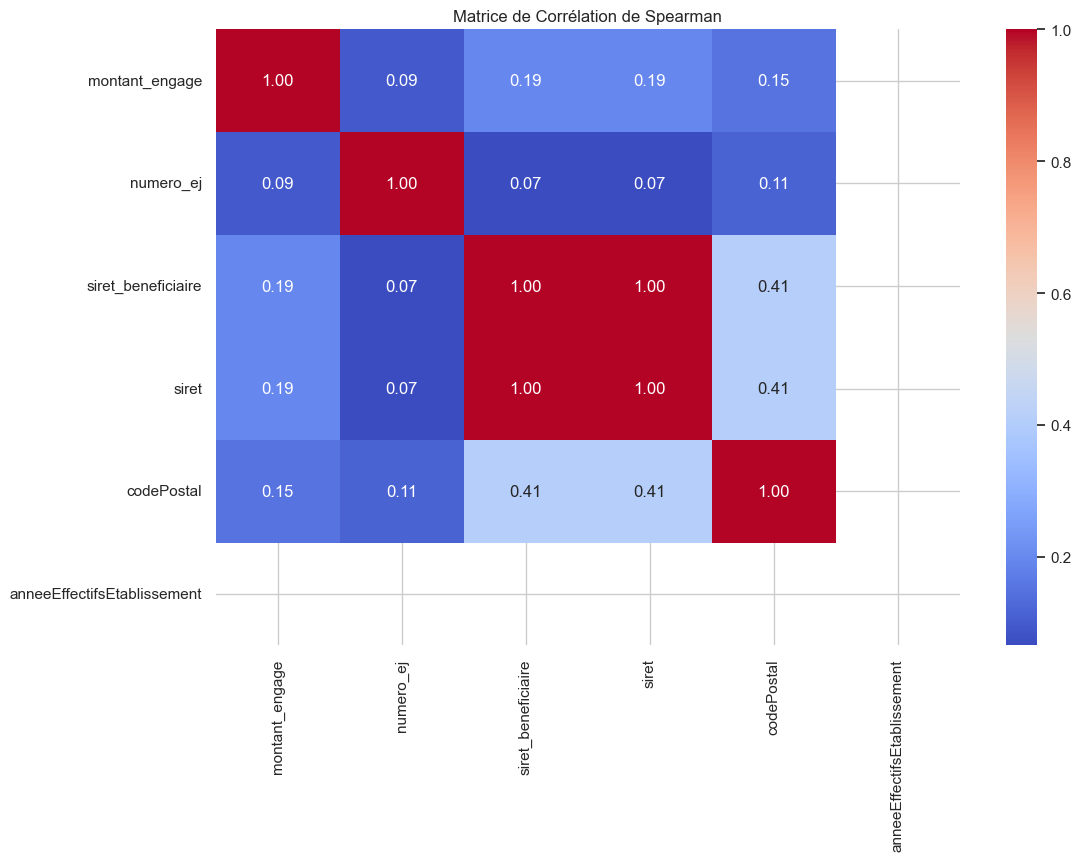


--- 2.3.2. Analyse des Dépendances (V de Cramer) ---


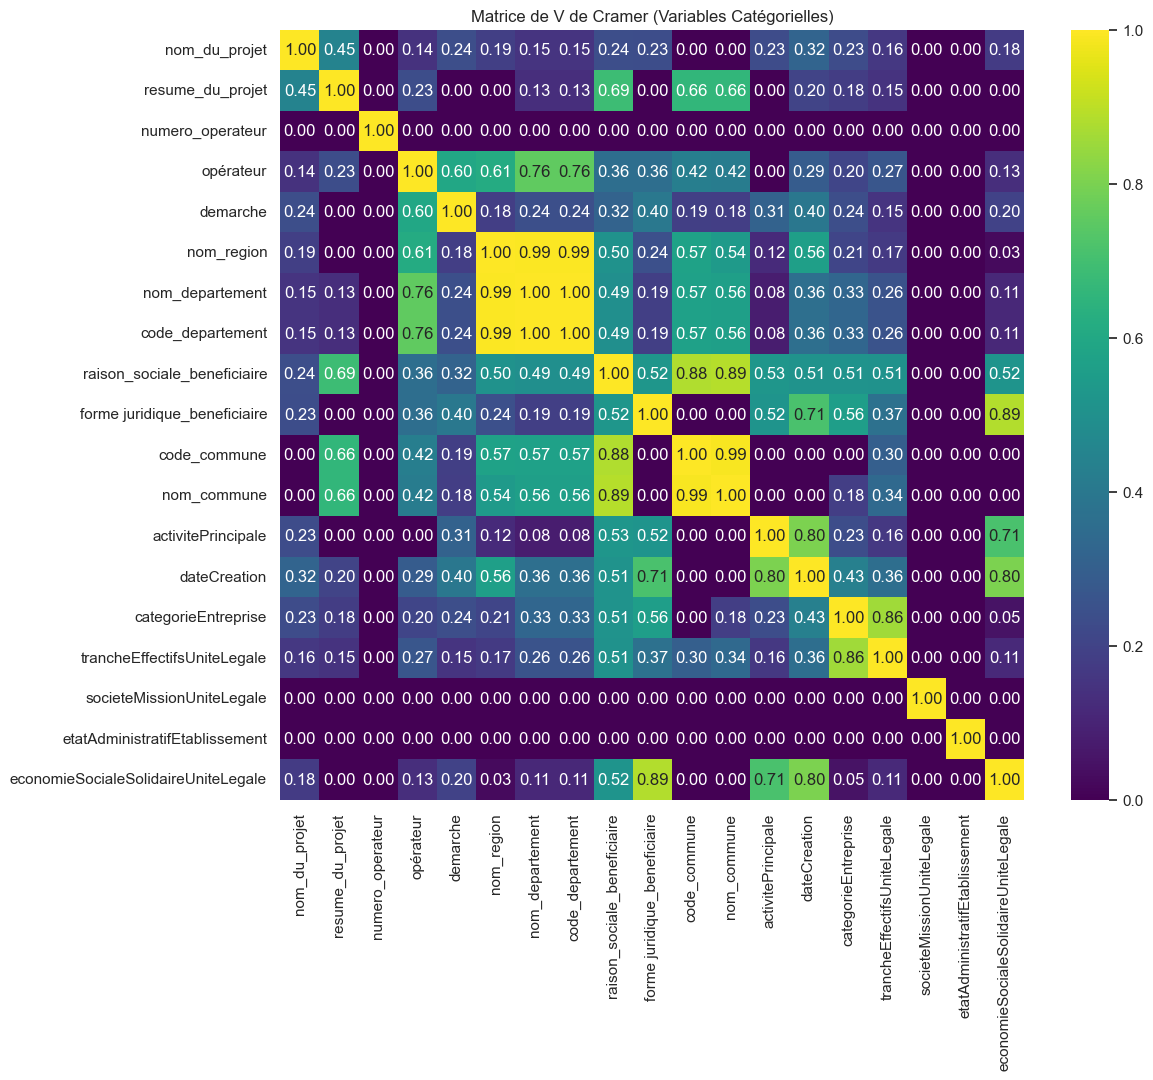

In [ ]:
def executer_analyse_bivariee(df, cols_num, cat_cols, show_corr=True, show_cramer=True, method='spearman'):
    """
    Exécute l'analyse bivariée complète :
    - Matrice de Corrélation (Pearson ou Spearman) pour les variables numériques.
    - Matrice de V de Cramer pour les variables catégorielles.
    
    Args:
        df: Le DataFrame à analyser.
        cols_num: Liste des colonnes numériques.
        cat_cols: Liste des colonnes catégorielles.
        show_corr (bool): Afficher la matrice de corrélation numérique.
        show_cramer (bool): Afficher la matrice de Cramer (catégorielles).
        method (str): Méthode de corrélation ('pearson' ou 'spearman'). Défaut: 'spearman'.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np
    from scipy.stats import chi2_contingency

    print("\n" + "="*60)
    print(f"2.3. ANALYSE BIVARIÉE ({method.capitalize()} & Cramer's V)")
    print("="*60 + "\n")

    # 1. Corrélation Numérique (Pearson/Spearman)
    if show_corr:
        print(f"--- 2.3.1. Corrélations de {method.capitalize()} (Numériques) ---")
        existing_num_cols = [c for c in cols_num if c in df.columns]
        if existing_num_cols:
            plt.figure(figsize=(12, 8))
            # Utilisation de la méthode spécifiée (pearson ou spearman)
            sns.heatmap(df[existing_num_cols].corr(method=method), annot=True, cmap='coolwarm', fmt=".2f")
            plt.title(f"Matrice de Corrélation de {method.capitalize()}")
            plt.show()
        else:
            print(f"Aucune variable numérique trouvée ou spécifiée pour {method.capitalize()}.")

    # 2. Cramer's V (Catégorielles)
    if show_cramer:
        print("\n--- 2.3.2. Analyse des Dépendances (V de Cramer) ---")
        
        def calculate_cramers_v(x, y):
            confusion_matrix = pd.crosstab(x, y)
            chi2 = chi2_contingency(confusion_matrix)[0]
            n = confusion_matrix.sum().sum()
            phi2 = chi2 / n
            r, k = confusion_matrix.shape
            phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
            rcorr = r - ((r-1)**2)/(n-1)
            kcorr = k - ((k-1)**2)/(n-1)
            if min((kcorr-1), (rcorr-1)) == 0: return 0.0
            return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

        existing_cat_cols = [c for c in cat_cols if c in df.columns]
        if len(existing_cat_cols) > 1:
            try:
                cramer_matrix = pd.DataFrame(index=existing_cat_cols, columns=existing_cat_cols)
                for col1 in existing_cat_cols:
                    for col2 in existing_cat_cols:
                        if col1 == col2: cramer_matrix.loc[col1, col2] = 1.0
                        else: cramer_matrix.loc[col1, col2] = calculate_cramers_v(df[col1], df[col2])
                
                cramer_matrix = cramer_matrix.astype(float)
                plt.figure(figsize=(12, 10))
                sns.heatmap(cramer_matrix, annot=True, fmt=".2f", cmap='viridis')
                plt.title("Matrice de V de Cramer (Variables Catégorielles)")
                plt.show()
            except Exception as e:
                print(f"Erreur lors du calcul de Cramer's V : {e}")
        else:
            print("Pas assez de variables catégorielles présentes pour Cramer.")

# Analyse bivariée sur toutes les variables initiales (df_train)
num_cols_eda = df_train.select_dtypes(include=['number']).columns.tolist()
# Auto-détection des variables catégorielles pour Cramer's V
cat_cols_eda = df_train.select_dtypes(include=['object', 'category']).columns.tolist()

executer_analyse_bivariee(df_train, num_cols_eda, cat_cols_eda)

### 2.5. Analyse des bases de données extérieures

### 2.5.1. Base de données d'entrainement `train.csv`

In [ ]:
# --- EXÉCUTION DU PIPELINE COMPLET SUR LE JEU D'ENTRAÎNEMENT ---

# Avec la nouvelle API simplifiée du DataOrchestrator, tout se fait en une ligne :
# 1. Nettoyage Structurel (Drop colonnes, Doublons, Outliers)
# 2. Feature Engineering (OneHot, TargetEncoding, FastText)
# 3. Sélection de Variables (VarianceThreshold)
# 4. Création du DataFrame final (X + y)

df_train_transformed_full = orchestrator.fit_transform(df_train)

# Affichage des résultats
print(f"\n✅ DataFrame Final : {df_train_transformed_full.shape}")
display(df_train_transformed_full.head())


# # --- SAUVEGARDE DU JEU DE DONNÉES TRANSFORMÉ ---

# os.makedirs('results', exist_ok=True)

# # Sauvegarde en CSV pour réutilisation future
# output_path = 'results/df_test_transformed_full.csv'
# df_train_transformed_full.to_csv(output_path, index=False)
# print(f"df_test_transformed_full sauvegardé dans '{output_path}'")


# # --- CHARGEMENT DU JEU DE DONNÉES (OPTIONNEL) ---
# input_path = 'results/df_test_transformed_full.csv'

# # Chargement direct depuis le fichier sauvegardé
# df_test_transformed_full = pd.read_csv(input_path)
# print(f"Données chargées : {df_test_transformed_full.shape}")
# display(df_test_transformed_full.head())


--- Orchestration : Fit & Transform (Train) ---
  [Orchestrator] Nettoyage structurel (is_train=True)...
  [Dedupliqueur] 1 doublons complets identifiés.
    -> Suppression (Mode Train).
  [NettoyeurAberrations] Analyse (is_train=True)...
 Aucune valeur aberrante détectée.
  [Orchestrator] Construction et Fit du pipeline FE...
  [FastText] Chargement du modèle depuis data/cc.fr.300.bin...
  [FastText] Modèle chargé.
✅ Transformation terminée : (7093, 624)

✅ DataFrame Final : (7093, 624)


,region_nom_Auvergne-Rhône-Alpes,region_nom_Bourgogne-Franche-Comté,region_nom_Bretagne,region_nom_Centre-Val de Loire,region_nom_Corse,region_nom_Grand Est,region_nom_Guadeloupe,region_nom_Guyane,region_nom_Hauts-de-France,region_nom_La Réunion,region_nom_Martinique,region_nom_Normandie,region_nom_Nouvelle-Aquitaine,region_nom_Nouvelle-Calédonie,region_nom_Occitanie,region_nom_Pays de la Loire,region_nom_Polynésie française,region_nom_Provence-Alpes-Côte d'Azur,region_nom_Saint-Barthélemy,region_nom_Saint-Martin,region_nom_Saint-Pierre-et-Miquelon,region_nom_Wallis-et-Futuna,region_nom_Île-de-France,region_nom_nan,departement_code_01,departement_code_02,departement_code_03,departement_code_04,departement_code_05,departement_code_06,departement_code_07,departement_code_08,departement_code_09,departement_code_10,departement_code_11,departement_code_12,departement_code_13,departement_code_14,departement_code_15,departement_code_16,departement_code_17,departement_code_18,departement_code_19,departement_code_21,departement_code_22,departement_code_23,departement_code_24,departement_code_25,departement_code_26,departement_code_27,departement_code_28,departement_code_29,departement_code_2A,departement_code_2B,departement_code_30,departement_code_31,departement_code_32,departement_code_33,departement_code_34,departement_code_35,departement_code_36,departement_code_37,departement_code_38,departement_code_39,departement_code_40,departement_code_41,departement_code_42,departement_code_43,departement_code_44,departement_code_45,departement_code_46,departement_code_47,departement_code_48,departement_code_49,departement_code_50,departement_code_51,departement_code_52,departement_code_53,departement_code_54,departement_code_55,departement_code_56,departement_code_57,departement_code_58,departement_code_59,departement_code_60,departement_code_61,departement_code_62,departement_code_63,departement_code_64,departement_code_65,departement_code_66,departement_code_67,departement_code_68,departement_code_69,departement_code_70,departement_code_71,departement_code_72,departement_code_73,departement_code_74,departement_code_75,departement_code_76,departement_code_77,departement_code_78,departement_code_79,departement_code_80,departement_code_81,departement_code_82,departement_code_83,departement_code_84,departement_code_85,departement_code_86,departement_code_87,departement_code_88,departement_code_89,departement_code_90,departement_code_91,departement_code_92,departement_code_93,departement_code_94,departement_code_95,departement_code_971,departement_code_972,departement_code_973,departement_code_974,departement_code_975,departement_code_977,departement_code_978,departement_code_986,departement_code_987,departement_code_988,departement_code_nan,categorie_juridique_code_(Autre) Collectivité territoriale,categorie_juridique_code_(Autre) Service déconcentré de l'État à compétence territoriale,categorie_juridique_code_(Autre) Établissement public administratif local,"categorie_juridique_code_Association de droit local (Bas-Rhin, Haut-Rhin et Moselle)",categorie_juridique_code_Association déclarée,"categorie_juridique_code_Association déclarée, reconnue d'utilité publique",categorie_juridique_code_Association syndicale autorisée,categorie_juridique_code_Autre SA coopérative à conseil d'administration,categorie_juridique_code_Autre SARL coopérative,categorie_juridique_code_Autre personne de droit privé inscrite au registre du commerce et des sociétés,categorie_juridique_code_Autre société civile,categorie_juridique_code_Autre établissement public national administratif à compétence territoriale limitée,categorie_juridique_code_Autre établissement public national d'enseignement,categorie_juridique_code_Centre Intercommunal d'action sociale (CIAS),categorie_juridique_code_Centre communal d'action sociale,categorie_juridique_code_Collectivité et territoire d'Outre Mer,categorie_juridique_code_Communauté d'agglomération,categorie_juridique_code_Communauté d

In [ ]:
# Inspection Structurelle
inspect_data_structure(df_train_transformed_full, name="Jeu d'Entraînement")


--- Inspection Structurelle : Jeu d'Entraînement ---
  Dimensions : 7093 lignes × 624 colonnes

  [Types de Variables]
float64    624
Name: count, dtype: int64

  [Taux de Remplissage (%)]
  ⚠️ categorie_entreprise                          :   96.9%
  ⚠️ tranche_effectifs                             :   97.7%
  ✅ fasttext_277                                  :  100.0%
  ✅ fasttext_278                                  :  100.0%
  ✅ fasttext_279                                  :  100.0%
  ✅ fasttext_280                                  :  100.0%
  ✅ fasttext_281                                  :  100.0%
  ✅ fasttext_282                                  :  100.0%
  ✅ fasttext_283                                  :  100.0%
  ✅ fasttext_284                                  :  100.0%
  ✅ fasttext_269                                  :  100.0%
  ✅ fasttext_270                                  :  100.0%
  ✅ fasttext_271                                  :  100.0%
  ✅ fasttext_272            


--- Analyse Univariée (Cible : montant_engage) ---
  Count:    7093
  Mean:     181,826.88
  Median:   63,259.00
  Std:      377,638.44
  Min:      287.50
  Max:      11,600,000.00
  Skewness: 10.46
  Kurtosis: 214.29


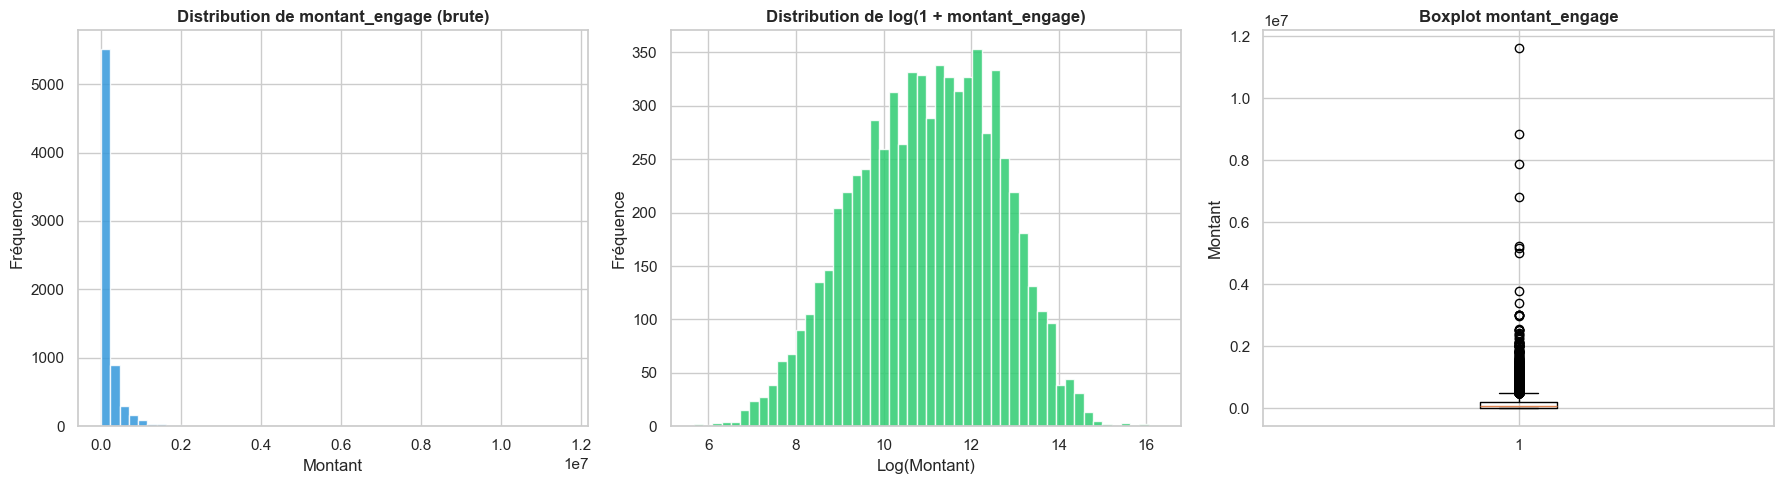


--- Cardinalité des Variables ---
  region_nom_Auvergne-Rhône-Alpes               :      2 uniques  (float64)
  region_nom_Bourgogne-Franche-Comté            :      2 uniques  (float64)
  region_nom_Bretagne                           :      2 uniques  (float64)
  region_nom_Centre-Val de Loire                :      2 uniques  (float64)
  region_nom_Corse                              :      2 uniques  (float64)
  region_nom_Grand Est                          :      2 uniques  (float64)
  region_nom_Guadeloupe                         :      2 uniques  (float64)
  region_nom_Guyane                             :      2 uniques  (float64)
  region_nom_Hauts-de-France                    :      2 uniques  (float64)
  region_nom_La Réunion                         :      2 uniques  (float64)
  region_nom_Martinique                         :      2 uniques  (float64)
  region_nom_Normandie                          :      2 uniques  (float64)
  region_nom_Nouvelle-Aquitaine                 :    

In [ ]:
# Analyse univariée
analyze_univariate(df_train_transformed_full, target_col='montant_engage')


2.3. ANALYSE BIVARIÉE (Spearman & Cramer's V)

--- 2.3.1. Corrélations de Spearman (Numériques) ---


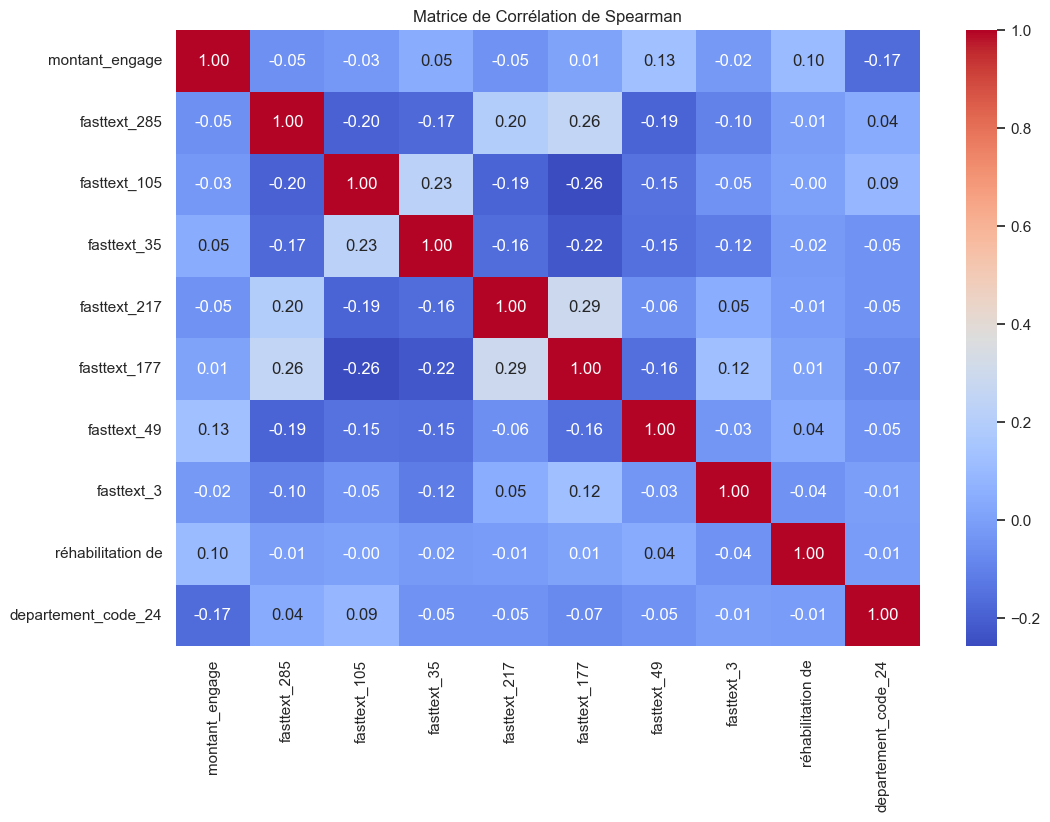


--- 2.3.2. Analyse des Dépendances (V de Cramer) ---
Pas assez de variables catégorielles présentes pour Cramer.


In [ ]:
# Analyse bivariée
import random
num_cols_eda = ['montant_engage'] + random.sample([c for c in df_train_transformed_full.select_dtypes('number').columns if c != 'montant_engage'], 9)
cat_cols_eda = []

executer_analyse_bivariee(df_train_transformed_full, num_cols_eda, cat_cols_eda)

### 2.5.2. Base de données test `test.csv`

In [ ]:
# Chargement des données
df_test = pd.read_csv('data/test.csv')

display(df_test.head(3))

,nom_du_projet,resume_du_projet,montant_engage,numero_ej,numero_operateur,opérateur,demarche,nom_region,nom_departement,code_departement,siret_beneficiaire,raison_sociale_beneficiaire,forme juridique_beneficiaire,code_commune,nom_commune,siret,activitePrincipale,codePostal,dateCreation,categorieEntreprise,trancheEffectifsUniteLegale,societeMissionUniteLegale,etatAdministratifEtablissement,anneeEffectifsEtablissement,economieSocialeSolidaireUniteLegale
0,Isolation thermique par l'extérieur de murs de...,Le projet porte sur des travaux d'isolation th...,35995.88,2.104329e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Centre-Val de Loire,Indre,36,2.136019e+13,COMMUNE DE SAINT GENOU,Commune et commune nouvelle,36194,Saint-Genou,2.136019e+13,84.11Z,36500.0,1983-03-01,PME,11,NaN,A,2023.0,NaN
1,Remplacement des têtes du reste du parc d'écla...,Dans le cadre de la transition écologique-éner...,2360.36,2.104327e+09,NaN,NaN,Rénovation des parcs de luminaires d’éclairage...,Nouvelle-Aquitaine,Haute-Vienne,87,2.187039e+13,COMMUNE DE CHATEAU CHERVIX,Commune et commune nouvelle,87039,Château-Chervix,2.187039e+13,84.11Z,87380.0,1983-03-01,PME,11,NaN,A,2023.0,N
2,Rénovation énergétique de l'école,Rénovation énergétique et extension de l’école...,137933.00,2.104325e+09,NaN,NaN,Rénovation énergétique des bâtiments publics l...,Bretagne,Ille-et-Vilaine,35,2.135034e+13,COMMUNE DE TRANS LA FORET,Commune et commune nouvelle,35339,Trans-la-Forêt,2.135034e+13,84.11Z,35610.0,1983-03-01,PME,03,NaN,A,2023.0,NaN


In [ ]:
# --- EXÉCUTION DU PIPELINE COMPLET SUR LE JEU DE TEST ---
df_test_transformed_full = orchestrator.transform(df_test)
display(df_test_transformed_full.head())


--- Orchestration : Transform (Inférence/Test) ---
  [Orchestrator] Nettoyage structurel (is_train=False)...
  [Dedupliqueur] Aucun doublon détecté.
  [NettoyeurAberrations] Analyse (is_train=False)...
 Aucune valeur aberrante détectée.
  [Orchestrator] Application du pipeline FE...
✅ Transformation terminée : (1774, 624)


,region_nom_Auvergne-Rhône-Alpes,region_nom_Bourgogne-Franche-Comté,region_nom_Bretagne,region_nom_Centre-Val de Loire,region_nom_Corse,region_nom_Grand Est,region_nom_Guadeloupe,region_nom_Guyane,region_nom_Hauts-de-France,region_nom_La Réunion,region_nom_Martinique,region_nom_Normandie,region_nom_Nouvelle-Aquitaine,region_nom_Nouvelle-Calédonie,region_nom_Occitanie,region_nom_Pays de la Loire,region_nom_Polynésie française,region_nom_Provence-Alpes-Côte d'Azur,region_nom_Saint-Barthélemy,region_nom_Saint-Martin,region_nom_Saint-Pierre-et-Miquelon,region_nom_Wallis-et-Futuna,region_nom_Île-de-France,region_nom_nan,departement_code_01,departement_code_02,departement_code_03,departement_code_04,departement_code_05,departement_code_06,departement_code_07,departement_code_08,departement_code_09,departement_code_10,departement_code_11,departement_code_12,departement_code_13,departement_code_14,departement_code_15,departement_code_16,departement_code_17,departement_code_18,departement_code_19,departement_code_21,departement_code_22,departement_code_23,departement_code_24,departement_code_25,departement_code_26,departement_code_27,departement_code_28,departement_code_29,departement_code_2A,departement_code_2B,departement_code_30,departement_code_31,departement_code_32,departement_code_33,departement_code_34,departement_code_35,departement_code_36,departement_code_37,departement_code_38,departement_code_39,departement_code_40,departement_code_41,departement_code_42,departement_code_43,departement_code_44,departement_code_45,departement_code_46,departement_code_47,departement_code_48,departement_code_49,departement_code_50,departement_code_51,departement_code_52,departement_code_53,departement_code_54,departement_code_55,departement_code_56,departement_code_57,departement_code_58,departement_code_59,departement_code_60,departement_code_61,departement_code_62,departement_code_63,departement_code_64,departement_code_65,departement_code_66,departement_code_67,departement_code_68,departement_code_69,departement_code_70,departement_code_71,departement_code_72,departement_code_73,departement_code_74,departement_code_75,departement_code_76,departement_code_77,departement_code_78,departement_code_79,departement_code_80,departement_code_81,departement_code_82,departement_code_83,departement_code_84,departement_code_85,departement_code_86,departement_code_87,departement_code_88,departement_code_89,departement_code_90,departement_code_91,departement_code_92,departement_code_93,departement_code_94,departement_code_95,departement_code_971,departement_code_972,departement_code_973,departement_code_974,departement_code_975,departement_code_977,departement_code_978,departement_code_986,departement_code_987,departement_code_988,departement_code_nan,categorie_juridique_code_(Autre) Collectivité territoriale,categorie_juridique_code_(Autre) Service déconcentré de l'État à compétence territoriale,categorie_juridique_code_(Autre) Établissement public administratif local,"categorie_juridique_code_Association de droit local (Bas-Rhin, Haut-Rhin et Moselle)",categorie_juridique_code_Association déclarée,"categorie_juridique_code_Association déclarée, reconnue d'utilité publique",categorie_juridique_code_Association syndicale autorisée,categorie_juridique_code_Autre SA coopérative à conseil d'administration,categorie_juridique_code_Autre SARL coopérative,categorie_juridique_code_Autre personne de droit privé inscrite au registre du commerce et des sociétés,categorie_juridique_code_Autre société civile,categorie_juridique_code_Autre établissement public national administratif à compétence territoriale limitée,categorie_juridique_code_Autre établissement public national d'enseignement,categorie_juridique_code_Centre Intercommunal d'action sociale (CIAS),categorie_juridique_code_Centre communal d'action sociale,categorie_juridique_code_Collectivité et territoire d'Outre Mer,categorie_juridique_code_Communauté d'agglomération,categorie_juridique_code_Communauté d

In [ ]:
# Inspection Structurelle
inspect_data_structure(df_test_transformed_full, name="Jeu de Test")


--- Inspection Structurelle : Jeu de Test ---
  Dimensions : 1774 lignes × 624 colonnes

  [Types de Variables]
float64    624
Name: count, dtype: int64

  [Taux de Remplissage (%)]
  ⚠️ categorie_entreprise                          :   97.0%
  ⚠️ tranche_effectifs                             :   97.6%
  ✅ fasttext_277                                  :  100.0%
  ✅ fasttext_278                                  :  100.0%
  ✅ fasttext_279                                  :  100.0%
  ✅ fasttext_280                                  :  100.0%
  ✅ fasttext_281                                  :  100.0%
  ✅ fasttext_282                                  :  100.0%
  ✅ fasttext_283                                  :  100.0%
  ✅ fasttext_284                                  :  100.0%
  ✅ fasttext_269                                  :  100.0%
  ✅ fasttext_270                                  :  100.0%
  ✅ fasttext_271                                  :  100.0%
  ✅ fasttext_272                   


--- Analyse Univariée (Cible : montant_engage) ---
  Count:    1774
  Mean:     185,226.37
  Median:   60,000.00
  Std:      417,504.37
  Min:      425.00
  Max:      8,921,761.00
  Skewness: 9.26
  Kurtosis: 140.82


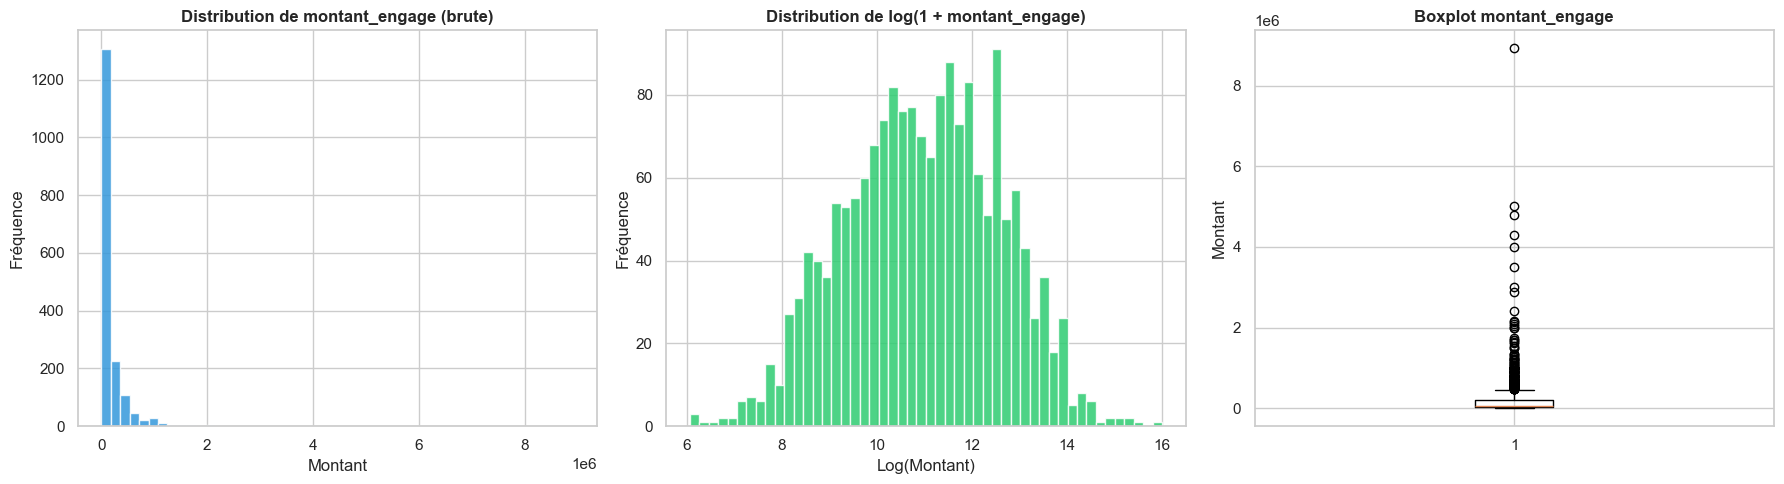


--- Cardinalité des Variables ---
  region_nom_Auvergne-Rhône-Alpes               :      2 uniques  (float64)
  region_nom_Bourgogne-Franche-Comté            :      2 uniques  (float64)
  region_nom_Bretagne                           :      2 uniques  (float64)
  region_nom_Centre-Val de Loire                :      2 uniques  (float64)
  region_nom_Corse                              :      2 uniques  (float64)
  region_nom_Grand Est                          :      2 uniques  (float64)
  region_nom_Guadeloupe                         :      2 uniques  (float64)
  region_nom_Guyane                             :      2 uniques  (float64)
  region_nom_Hauts-de-France                    :      2 uniques  (float64)
  region_nom_La Réunion                         :      2 uniques  (float64)
  region_nom_Martinique                         :      2 uniques  (float64)
  region_nom_Normandie                          :      2 uniques  (float64)
  region_nom_Nouvelle-Aquitaine                 :    

In [ ]:
# Analyse univariée
analyze_univariate(df_test_transformed_full, target_col='montant_engage')


2.3. ANALYSE BIVARIÉE (Spearman & Cramer's V)

--- 2.3.1. Corrélations de Spearman (Numériques) ---


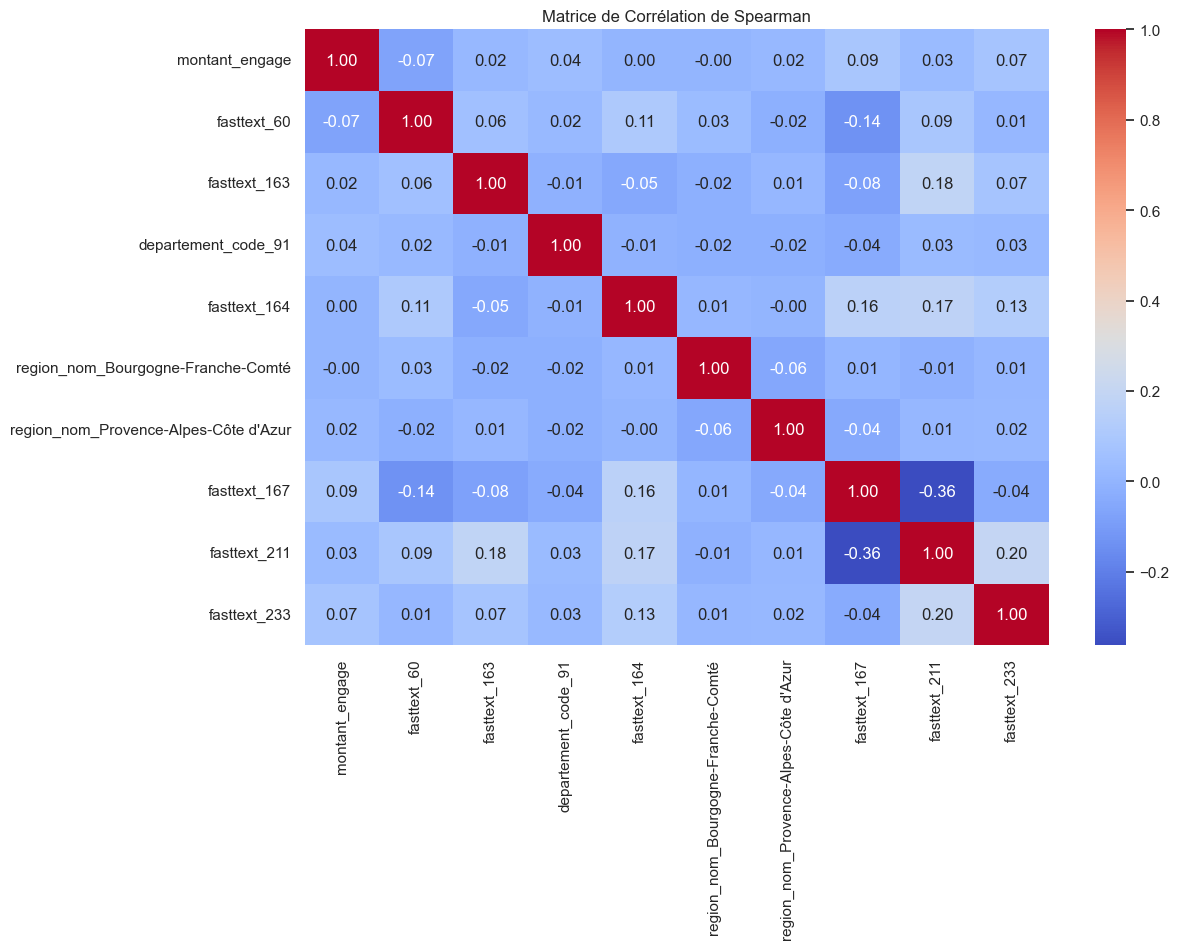


--- 2.3.2. Analyse des Dépendances (V de Cramer) ---
Pas assez de variables catégorielles présentes pour Cramer.


In [ ]:
# Analyse bivariée
import random
num_cols_eda = ['montant_engage'] + random.sample([c for c in df_test_transformed_full.select_dtypes('number').columns if c != 'montant_engage'], 9)
cat_cols_eda = []

executer_analyse_bivariee(df_test_transformed_full, num_cols_eda, cat_cols_eda)

## 3. Stratégie de Modélisation
### 3.1. Stratégie de Validation & Optimisation
*   **Méthode** : **Stratified K-Fold Regression**.
    *   *Technique* : Discrétisation (Binning) de la cible continue en quantiles temporaires -> Stratification sur ces bins.
    *   *Objectif* : Garantir représentativité des extrêmes dans chaque fold.
*   **Paramètre K (Folds)** :
    *   **k=5** : Standard (Random Forest, Boosting, AdaBoost) -> Compromis Biais/Variance/Coût.
    *   **k=10** : Exception (Decision Tree) -> Estimation fine variance sur modèle instable rapide.
*   **Analyse Sensibilité Hyperparamètres** :
    *   **Visualisation** : Heatmaps 2D/3D avec `seaborn` (Performance vs Params).
    *   **Analyse** : Résultats bruts `cv_results_` pour stabilité optimum et éviter solutions de bord.

In [ ]:
# --- Préparation des Données & Stratégie de Validation (Conforme Partie 3.1) ---

print("--- 1. Préparation des Données pour Modélisation ---")
# On utilise les DataFrames déjà transformés par l'Orchestrateur (Cell 26)
if 'df_train_transformed_full' not in locals():
    # Sécurité si la cellule précédente n'a pas été exécutée
    print("Warning: df_train_transformed_full introuvable, relance de l'orchestrateur...")
    # On suppose que l'orchestrateur existe dans le notebook
    try:
        df_train_transformed_full = orchestrator.fit_transform(df_train)
    except:
        print("Erreur: Orchestrator introuvable. Exécutez les cellules précédentes.")

# Séparation X, y pour l'entraînement
X = df_train_transformed_full.drop(columns=['montant_engage'])
y = df_train_transformed_full['montant_engage']

# Feature names (pour certaines méthodes d'interprétabilité)
feature_names = X.columns.tolist()

print(f"✅ Données prêtes : X={X.shape}, y={y.shape}")

# --- 2. Protocole de Validation Croisée Stratifiée ---
# Comme il s'agit d'une régression, on doit discrétiser la cible continue pour stratifier

# Création de 10 classes (bins) basées sur les quantiles du montant engagé
n_bins = 10
try:
    y_binned = pd.qcut(y, q=n_bins, labels=False, duplicates='drop')
except ValueError:
    print("Warning: Pas assez de données distinctes pour 10 quantiles, fallback à 5.")
    y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

print(f"✅ Stratification active sur {y_binned.nunique()} classes de montants.")

# --- 3. Génération des Splits (Listes d'indices) ---
# K=5 : Standard pour Random Forest, XGBoost, etc. (Compromis Biais/Variance)
skf_standard = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_standard_splits = list(skf_standard.split(X, y_binned))

# K=10 : Spécifique pour Arbres de Décision (Estimateur instable -> besoin de plus de plis)
skf_tree = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_tree_splits = list(skf_tree.split(X, y_binned))

print(f"✅ Stratégies CV définies : cv_standard_splits (k=5) et cv_tree_splits (k=10). Indices pré-calculés.")

--- 1. Préparation des Données pour Modélisation ---
✅ Données prêtes : X=(7093, 623), y=(7093,)
✅ Stratification active sur 10 classes de montants.
✅ Stratégies CV définies : cv_standard_splits (k=5) et cv_tree_splits (k=10). Indices pré-calculés.


#### A. Decision Tree Regressor (Modèle "Boîte Blanche")
---
*   **Fonction associée :** `entrainer_decision_tree`
*   **Validation Croisée :** **Stratified K-Fold (k=10)**
    > *Exception au standard (k=5) justifiée par la rapidité du modèle, permettant une estimation plus fine de la variance.*
*   **Optimisation :** **GridSearchCV**
    > *Recherche exhaustive sur un espace fini (`max_depth`, `min_samples_leaf`).*
*   **Hyperparamètres Clés :**
    *   `max_depth` : [3, 5, 7, 10, None]
    *   `min_samples_leaf` : [1, 2, 5, 10]
    *   `criterion` : ["squared_error", "friedman_mse"]
*   **Interprétabilité :**
    *   **Globale :** `plot_tree` (Structure explicite), Feature Importance (Gini).
    *   **Locale :** Decision Path.

In [ ]:
# A. Decision Tree Regressor (Modèle "Boîte Blanche")
print("--- Entraînement : Decision Tree Regressor ---")

# 1. Pipeline Modèle
# Pas de preprocessor interne : X est déjà prêt.
tree_model = DecisionTreeRegressor(random_state=42)

# 2. Gestion de la Cible (Box-Cox) via TransformedTargetRegressor
tree_model_final = TransformedTargetRegressor(
    regressor=tree_model,
    transformer=PowerTransformer(method='box-cox')
)

# 3. Grille d'Hyperparamètres
# Exploration exhaustive (GridSearchCV)
# Prefixe 'regressor__' car dans TransformedTargetRegressor
param_grid_tree = {
    'regressor__max_depth': [3, 5, 7, 10, 15, None],
    'regressor__min_samples_leaf': [1, 2, 5, 10],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__criterion': ['squared_error', 'friedman_mse'],
    'regressor__splitter': ['best', 'random'],
    'regressor__ccp_alpha': [0.0, 0.001, 0.01] 
}

# # 4a. Recherche sur Grille (Exhaustive)
# # Utilisation de la CV pré-calculée
# print(f"Lancement GridSearchCV Tree (k=10)...")
# grid_tree = GridSearchCV(
#     tree_model_final,
#     param_grid=param_grid_tree,
#     cv=cv_tree_splits,
#     scoring='r2',
#     n_jobs=-1,
#     verbose=1
# )
# grid_tree.fit(X, y)
# print(f"✅ Meilleur R² (GridSearchCV): {grid_tree.best_score_:.4f}")
# print(f"✅ Meilleurs params (Grid): {grid_tree.best_params_}")

# 4b. Recherche Aléatoire (Alternative Rapide)
print(f"\nLancement RandomizedSearchCV Tree (k=10, iter=50)...")
random_search_tree = RandomizedSearchCV(
    tree_model_final,
    param_distributions=param_grid_tree,
    n_iter=5,
    cv=cv_tree_splits, 
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Sécurité Box-Cox (Appliquée aux deux)
if (y <= 0).any():
    print("  Info: Cible contient des valeurs <= 0, bascule vers Yeo-Johnson.")
    tree_model_final.transformer = PowerTransformer(method='yeo-johnson')

# Lancement

# print(f"Lancement GridSearchCV Decision Tree (k=5)...")
# grid_tree.fit(X, y)
# print(f"✅ Meilleur R² (CV Stratifiée): {grid_tree.best_score_:.4f}")
# print(f"✅ Meilleurs paramètres : {grid_tree.best_params_}")

print(f"Lancement RandomizedSearchCV Decision Tree (k=5)...")
random_search_tree.fit(X, y)
print(f"✅ Meilleur R² (CV Stratifiée): {random_search_tree.best_score_:.4f}")
print(f"✅ Meilleurs paramètres : {random_search_tree.best_params_}")

--- Entraînement : Decision Tree Regressor ---

Lancement RandomizedSearchCV Tree (k=10, iter=50)...
Lancement RandomizedSearchCV Decision Tree (k=5)...
Fitting 10 folds for each of 5 candidates, totalling 50 fits
✅ Meilleur R² (CV Stratifiée): 0.0859
✅ Meilleurs paramètres : {'regressor__splitter': 'best', 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 10, 'regressor__max_depth': None, 'regressor__criterion': 'friedman_mse', 'regressor__ccp_alpha': 0.01}


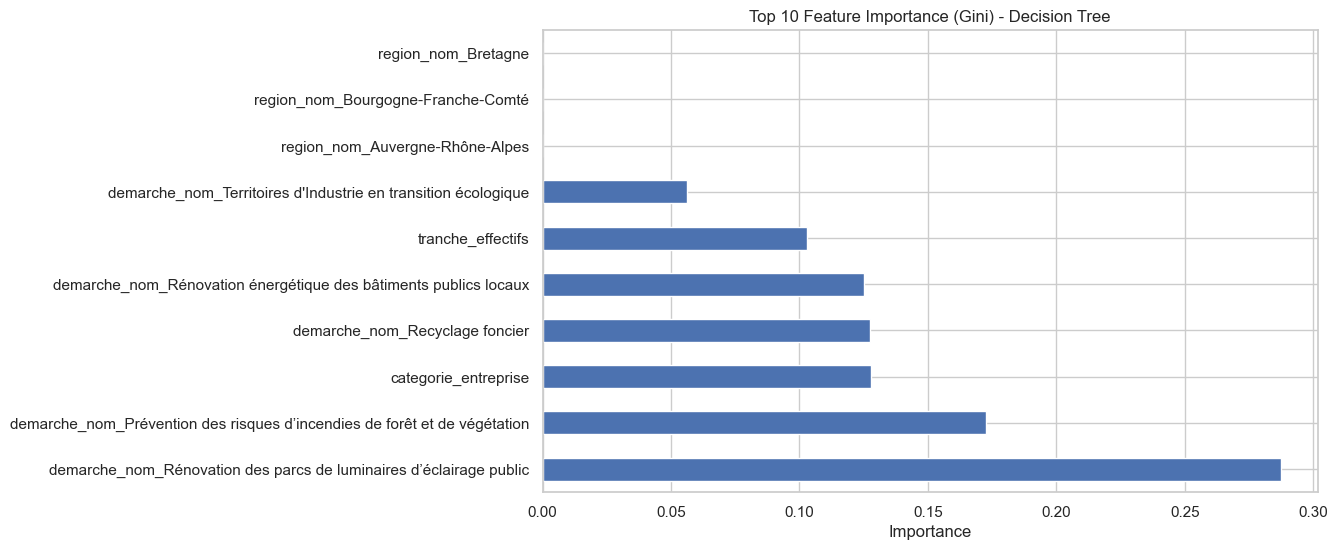

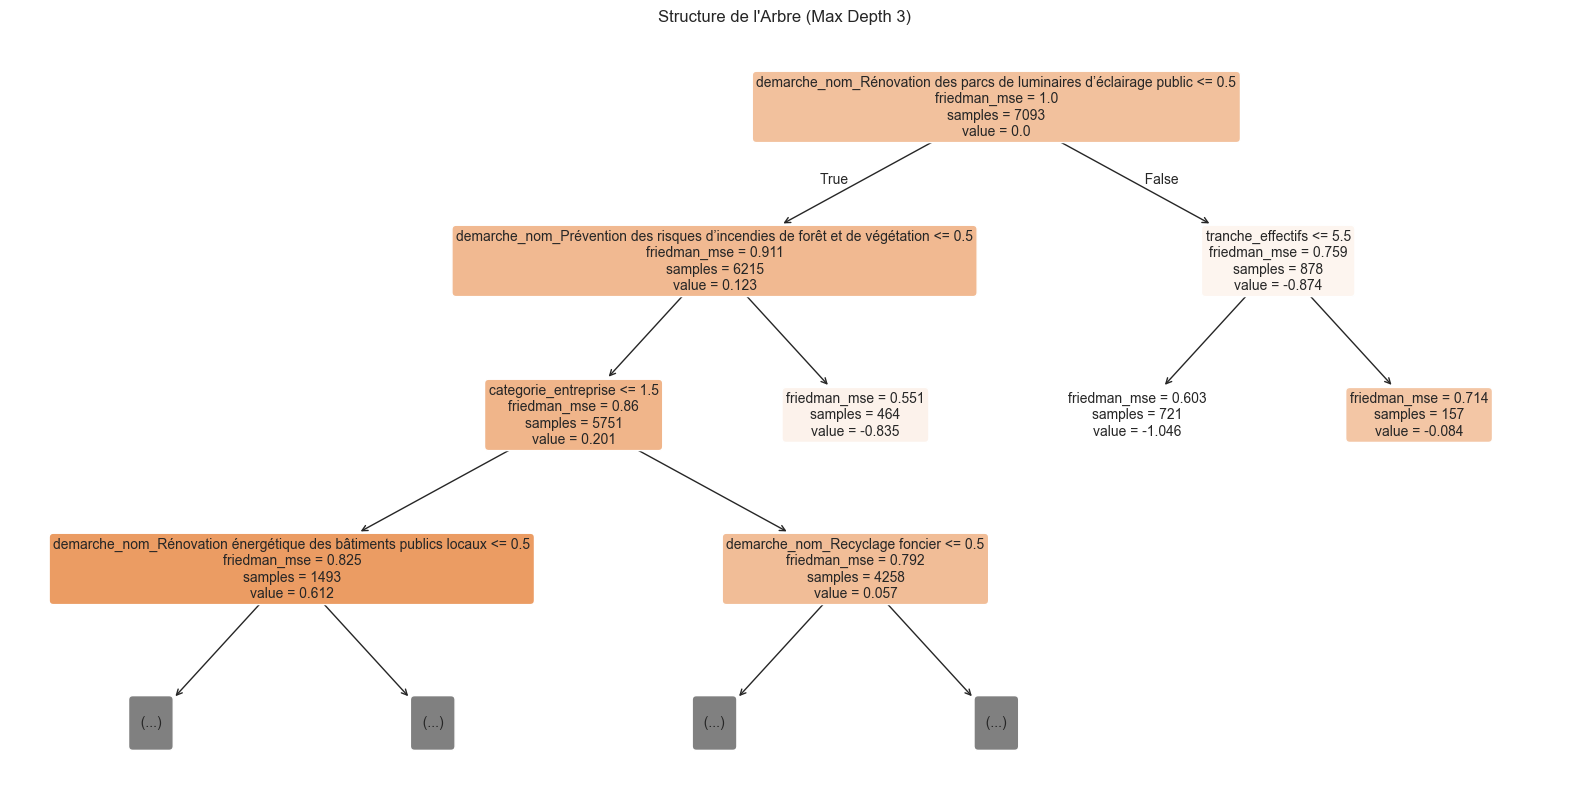


--- Decision Path pour l'échantillon 0 (Feuille 15) ---


In [ ]:
# --- Interprétabilité Decision Tree ---
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import plot_tree

# 1. Feature Importance (Gini)
# best_estimator_ est un TransformedTargetRegressor
best_tree = random_search_tree.best_estimator_.regressor_ 
# X est supposé être le DataFrame processé (cf commentaire cellule précédente)
feature_names = X.columns if hasattr(X, 'columns') else [f'F{i}' for i in range(X.shape[1])]

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_tree.feature_importances_, index=feature_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importance (Gini) - Decision Tree")
plt.xlabel("Importance")
plt.show()

# 2. Visualisation de l'Arbre (Profondeur limitée pour lisibilité)
plt.figure(figsize=(20, 10))
plot_tree(best_tree, max_depth=3, feature_names=list(feature_names), filled=True, fontsize=10, rounded=True)
plt.title("Structure de l'Arbre (Max Depth 3)")
plt.show()

# 3. Decision Path (Exemple pour le 1er individu)
sample_id = 0
# Retrieve the node indicator
node_indicator = best_tree.decision_path(X.iloc[[sample_id]])
leaf_id = best_tree.apply(X.iloc[[sample_id]])[0]
print(f"\n--- Decision Path pour l'échantillon {sample_id} (Feuille {leaf_id}) ---")
# On pourrait afficher le chemin détaillé ici


#### B. Random Forest Regressor (Bagging)
---
*   **Fonction associée :** `entrainer_random_forest`
*   **Validation Croisée :** **Stratified K-Fold (k=5)**
    > *Indispensable pour stabiliser l'évaluation du Bagging sur des distributions asymétriques.*
*   **Optimisation :** **RandomizedSearchCV**
    > *50-100 itérations aléatoires sur un espace combinatoire vaste.*
*   **Hyperparamètres Clés :**
    *   `n_estimators` : [100, 300, 500]
    *   `max_depth` : [10, 20, 30, None]
    *   `max_features` : ["sqrt", "log2", 0.8]
*   **Interprétabilité :**
    *   **Globale :** Permutation Importance (Robustesse), MDI (Rapidité).
    *   **Locale :** SHAP (TreeExplainer).

In [ ]:
# B. Random Forest Regressor (Bagging)
print("--- Entraînement : Random Forest Regressor ---")

# 1. Modèle & Transformation de Cible
rf_model_final = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=42, n_jobs=-1),
    transformer=PowerTransformer(method='box-cox')
)

# 2. Grille d'Hyperparamètres
# Optimisation : Nombre d'arbres, Profondeur, Echantillonnage
param_dist_rf = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__max_depth': [10, 20, 30, None],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2'],
    'regressor__bootstrap': [True]
}

# 3. Recherche Aléatoire (RandomizedSearchCV)
# Utilisation de la CV pré-calculée en X65 (cv_standard_splits)
random_search_rf = RandomizedSearchCV(
    rf_model_final,
    param_distributions=param_dist_rf,
    n_iter=5,
    cv=cv_standard_splits, 
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Sécurité Box-Cox
if (y <= 0).any():
    print("  Info: Cible contient des valeurs <= 0, bascule vers Yeo-Johnson.")
    rf_model_final.transformer = PowerTransformer(method='yeo-johnson')

# Lancement
print(f"Lancement RandomizedSearchCV Random Forest (k=5)...")
random_search_rf.fit(X, y)
print(f"✅ Meilleur R² (CV Stratifiée): {random_search_rf.best_score_:.4f}")
print(f"✅ Meilleurs paramètres : {random_search_rf.best_params_}")

--- Entraînement : Random Forest Regressor ---
Lancement RandomizedSearchCV Random Forest (k=5)...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
✅ Meilleur R² (CV Stratifiée): 0.0521
✅ Meilleurs paramètres : {'regressor__n_estimators': 100, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 20, 'regressor__bootstrap': True}


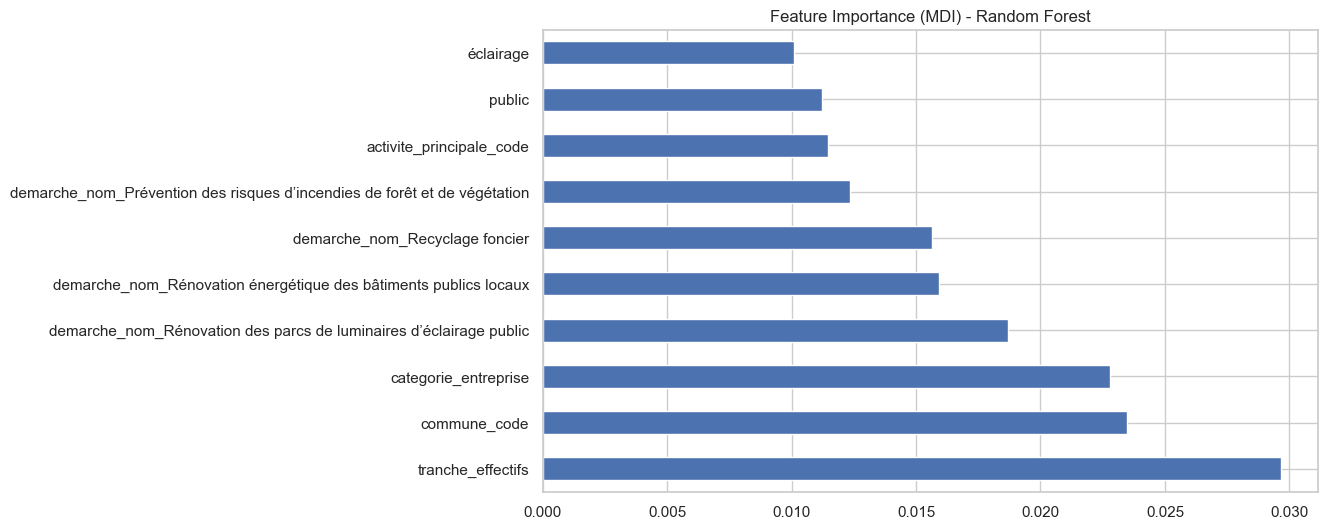

Calcul Permutation Importance (k=5)...


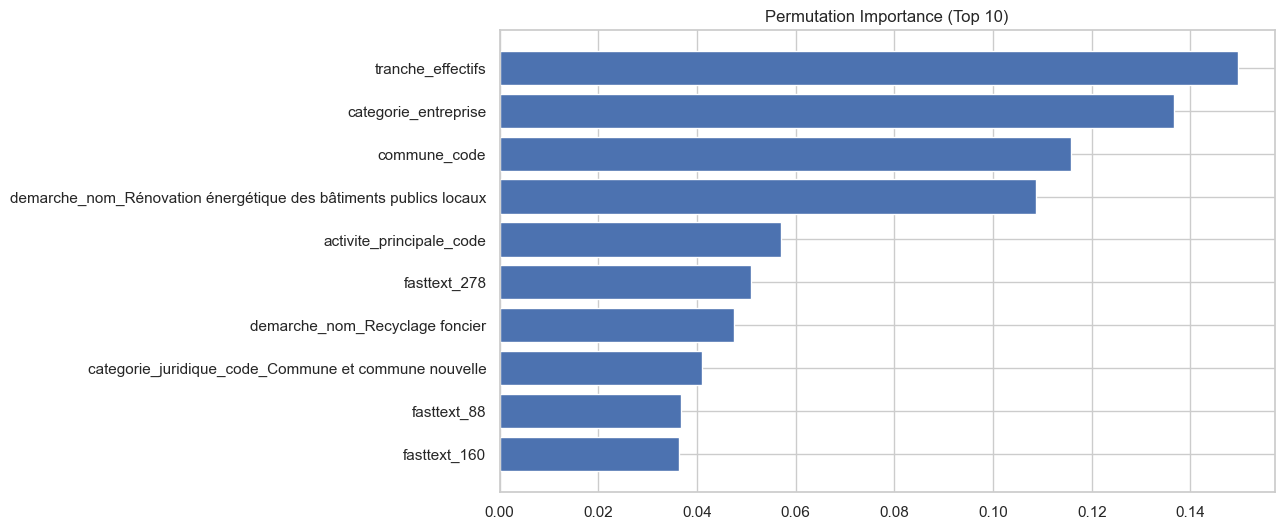

Calcul SHAP Values...


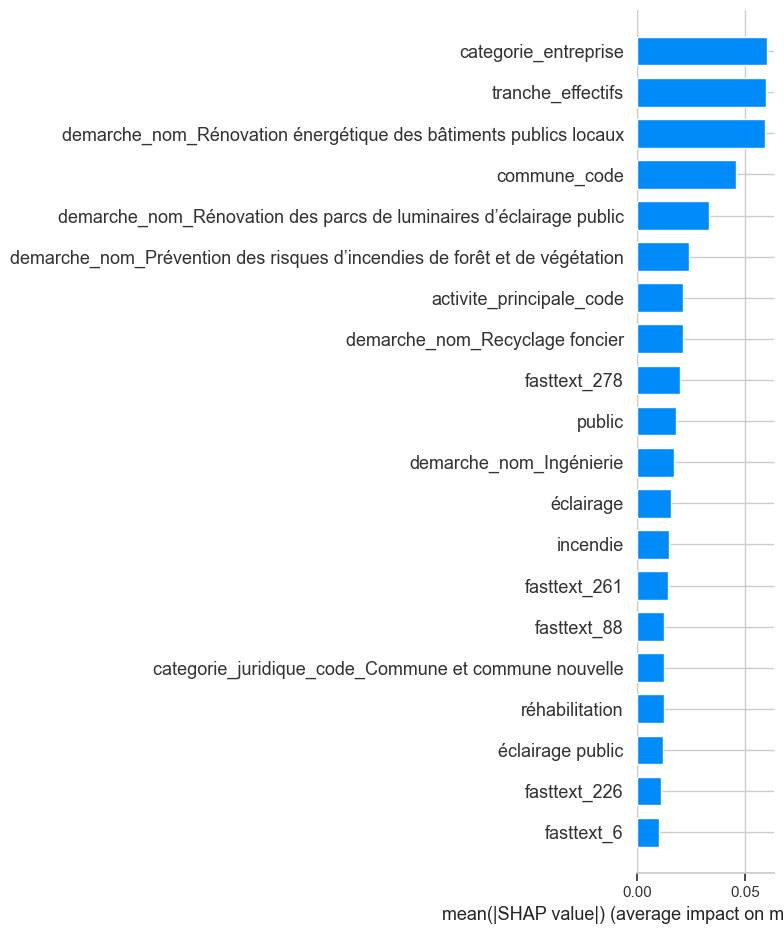

In [ ]:
# --- Interprétabilité Random Forest ---
from sklearn.inspection import permutation_importance
import shap

# best_estimator_ est un TransformedTargetRegressor
best_rf_ttr = random_search_rf.best_estimator_
best_rf = best_rf_ttr.regressor_

feature_names = X.columns if hasattr(X, 'columns') else [f'F{i}' for i in range(X.shape[1])]

# 1. Feature Importance MDI (Mean Decrease Impurity)
plt.figure(figsize=(10, 6))
mdi_importances = pd.Series(best_rf.feature_importances_, index=feature_names)
mdi_importances.nlargest(10).plot(kind='barh')
plt.title("Feature Importance (MDI) - Random Forest")
plt.show()

# 2. Permutation Importance (Sur Train Sample pour rapidité, normalement sur Test/Val)
# On utilise best_rf_ttr (modèle complet) et X, y.
print("Calcul Permutation Importance (k=5)...")
# Note: Sur gros dataset, ça peut être long. On prend un sous-échantillon si nécessaire
X_sample = X.iloc[:500] if len(X) > 500 else X
y_sample = y.iloc[:500] if len(y) > 500 else y
perm_importance = permutation_importance(best_rf_ttr, X_sample, y_sample, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm_importance.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_importance.importances_mean[sorted_idx])
plt.yticks(range(10), np.array(feature_names)[sorted_idx])
plt.title("Permutation Importance (Top 10)")
plt.show()

# 3. SHAP (TreeExplainer)
# Appliqué sur le modèle interne (best_rf) et données transformées (X)
print("Calcul SHAP Values...")
explainer = shap.TreeExplainer(best_rf)
# Sur un échantillon pour la performance
shap_values = explainer.shap_values(X.iloc[:100])
plt.figure()
shap.summary_plot(shap_values, X.iloc[:100], plot_type="bar")
plt.show()


#### C. XGBoost Regressor (Boosting)
---
*   **Validation Croisée :** **Stratified K-Fold (k=5)**
*   **Optimisation :** **RandomizedSearchCV**
*   **Hyperparamètres Clés :**
    *   `learning_rate` : [0.01, 0.05, 0.1, 0.2]
    *   `n_estimators` : [100, 500, 1000]
    *   `max_depth` : [3, 5, 7]
    *   `subsample` / `colsample_bytree` : [0.6, 0.8, 1.0]
    *   `reg_alpha` / `reg_lambda` : [0, 0.1, 1, 10]
*   **Interprétabilité :**
    *   **Globale :** Gain/Weight Importance, Permutation Importance.
    *   **Locale :** SHAP (TreeExplainer).

In [ ]:
# C. XGBoost Regressor (Boosting)
print("--- Entraînement : XGBoost Regressor ---")

# 1. Modèle & Transformation
xhr_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

xgb_model_final = TransformedTargetRegressor(
    regressor=xhr_model,
    transformer=PowerTransformer(method='box-cox')
)

# 2. Grille d'Hyperparamètres
# Nomenclature 'regressor__' simple car pas de pipeline interne
param_dist_xgb = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__n_estimators': [100, 500, 1000],
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_child_weight': [1, 3, 5],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__reg_alpha': [0, 0.1, 1, 10],
    'regressor__reg_lambda': [0, 0.1, 1, 10],
    'regressor__gamma': [0, 0.1, 1.0, 5.0],
}

# 3. Recherche Aléatoire
random_search_xgb = RandomizedSearchCV(
    xgb_model_final,
    param_distributions=param_dist_xgb,
    n_iter=5,
    cv=cv_standard_splits,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

if (y <= 0).any():
    xgb_model_final.transformer = PowerTransformer(method='yeo-johnson')

# Lancement
print(f"Lancement RandomizedSearchCV XGBoost: n_iter=50...")
random_search_xgb.fit(X, y)
print(f"✅ Meilleur R² (CV): {random_search_xgb.best_score_:.4f}")
print(f"✅ Meilleurs params: {random_search_xgb.best_params_}")

--- Entraînement : XGBoost Regressor ---
Lancement RandomizedSearchCV XGBoost: n_iter=50...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
✅ Meilleur R² (CV): 0.2010
✅ Meilleurs params: {'regressor__subsample': 0.8, 'regressor__reg_lambda': 10, 'regressor__reg_alpha': 0.1, 'regressor__n_estimators': 1000, 'regressor__min_child_weight': 3, 'regressor__max_depth': 5, 'regressor__learning_rate': 0.2, 'regressor__gamma': 1.0, 'regressor__colsample_bytree': 1.0}


<Figure size 1000x600 with 0 Axes>

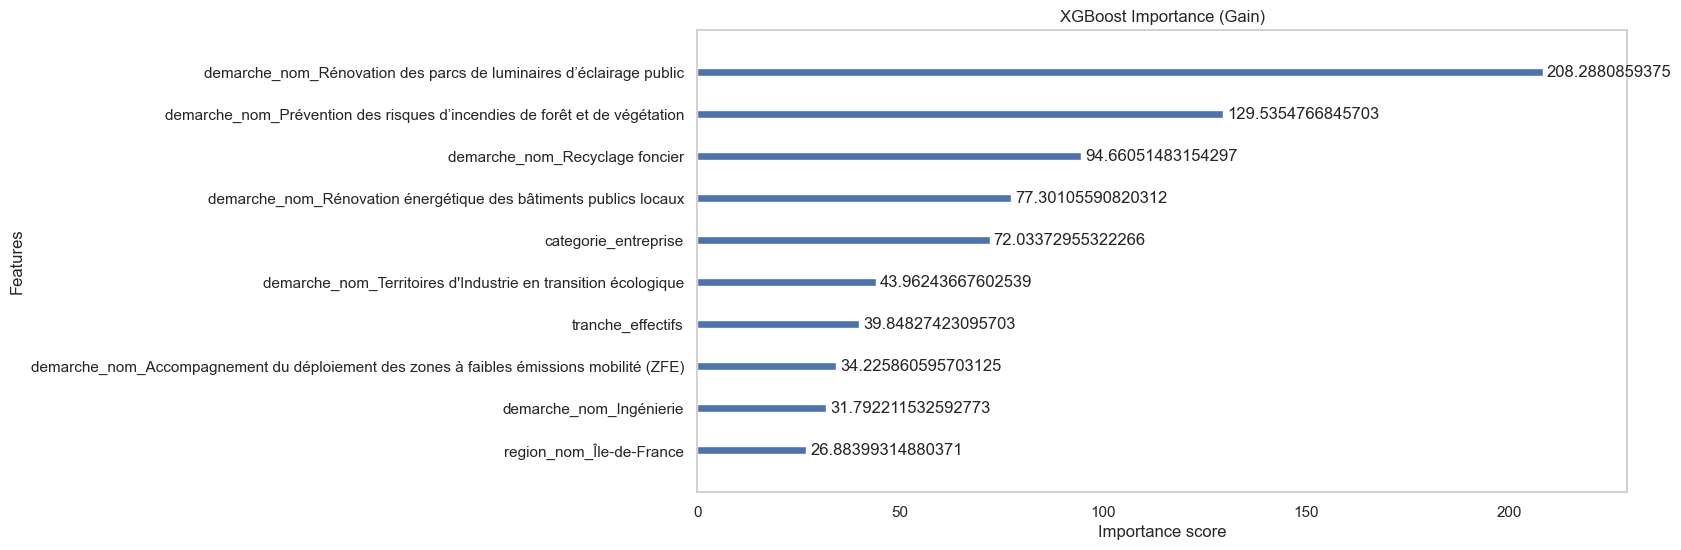

Calcul Permutation Importance XGBoost (sur sample de 500)...


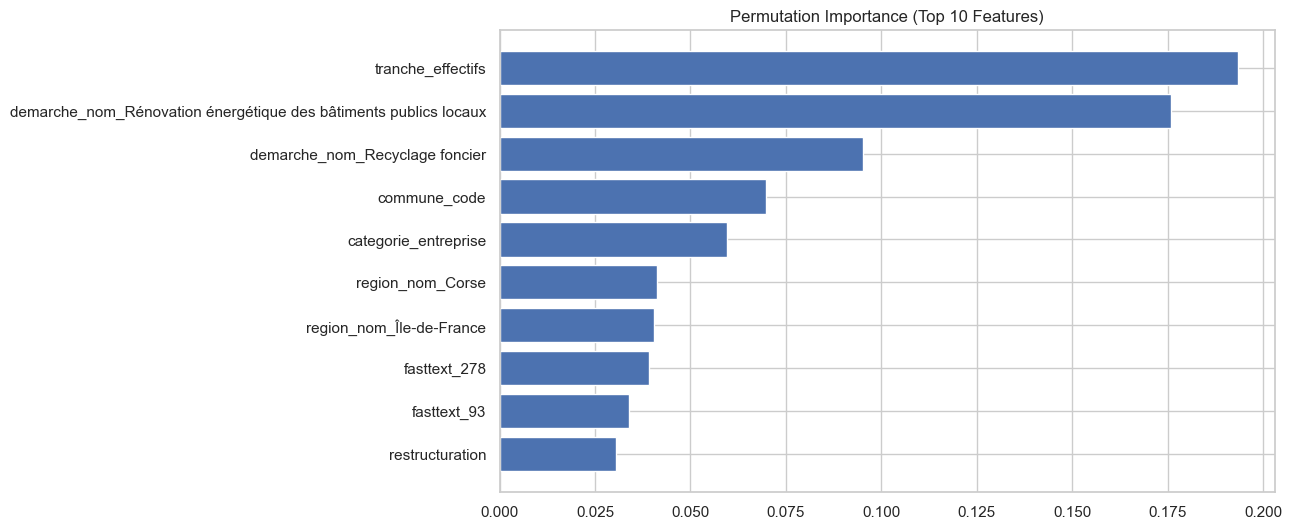

Analyse SHAP (sur sample de 100)...


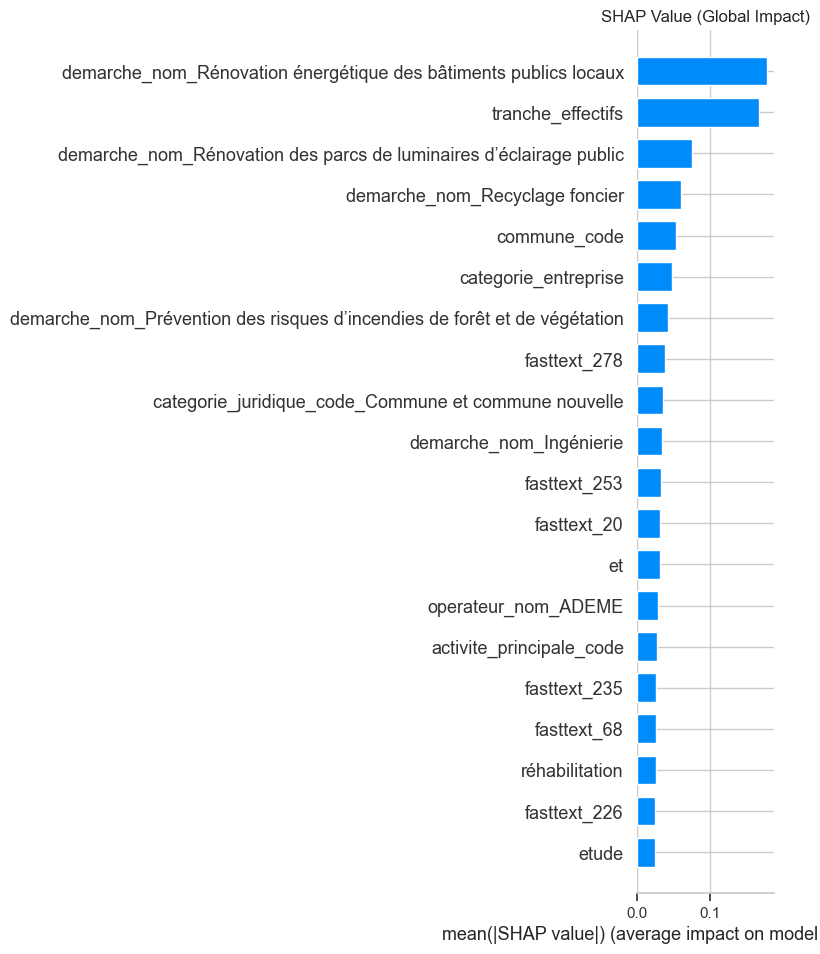

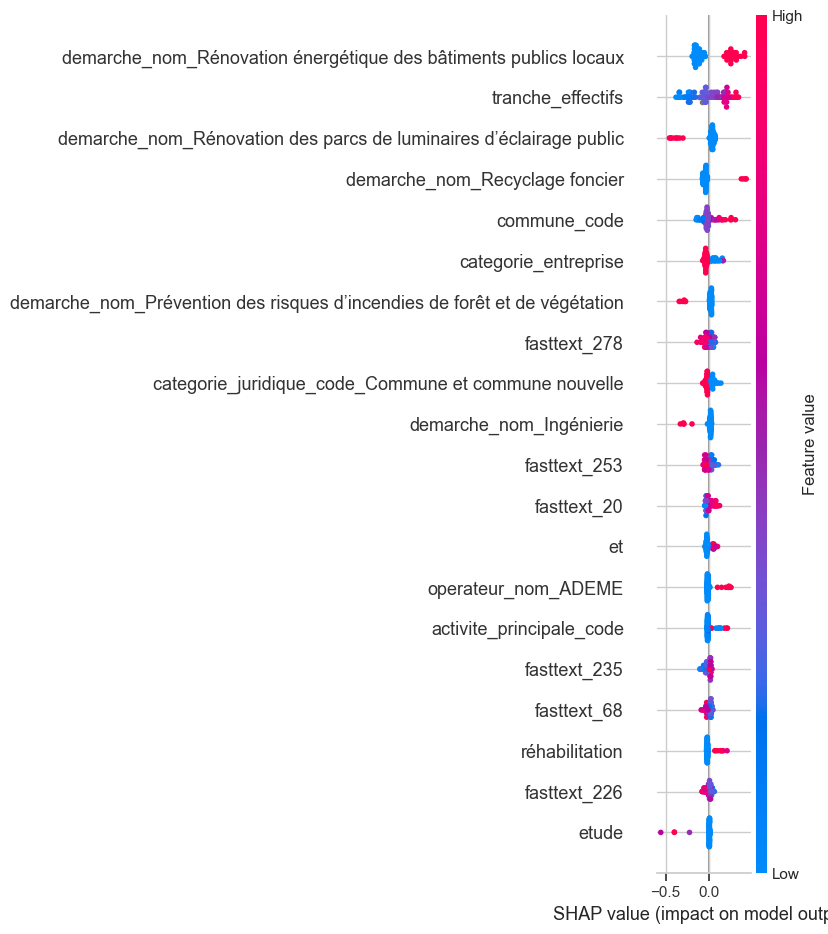

In [ ]:
# --- Interprétabilité XGBoost ---
import shap
import xgboost as xgb
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Récupération de l'estimateur et détection de structure
best_xgb_ttr = random_search_xgb.best_estimator_
model_internal = best_xgb_ttr.regressor_

if hasattr(model_internal, 'named_steps'):
    # Cas Pipeline (utilisé pour d'autres modèles)
    best_xgb = model_internal.named_steps['regressor']
    preprocessor = model_internal.named_steps['preprocessor']
    X_sample_source = X_train_clean if 'X_train_clean' in locals() else X
else:
    # Cas Regresseur direct (XGBoost ici car X est déjà pré-traité)
    best_xgb = model_internal
    preprocessor = None
    X_sample_source = X

# Récupération noms de features
try:
    if preprocessor is not None and hasattr(preprocessor, 'get_feature_names_out'):
        feature_names = preprocessor.get_feature_names_out()
    else:
        # Fallback sur les colonnes de X
        feature_names = X.columns.tolist()
except:
    feature_names = [f'F{i}' for i in range(X.shape[1])]

# --- 1. Feature Importance (Gain) ---
booster = best_xgb.get_booster()
try:
    booster.feature_names = list(feature_names)
except:
    pass

plt.figure(figsize=(10, 6))
xgb.plot_importance(booster, max_num_features=10, importance_type='gain', 
                   title='XGBoost Importance (Gain)', grid=False)
plt.show()

# --- 2. Permutation Importance ---
print('Calcul Permutation Importance XGBoost (sur sample de 500)...')
X_sample = X_sample_source.iloc[:500]
y_sample = y.iloc[:500] if 'y' in locals() else y_train_full.iloc[:500]

perm_xgb = permutation_importance(best_xgb_ttr, X_sample, y_sample, n_repeats=5, n_jobs=-1, random_state=42)
sorted_idx = perm_xgb.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_xgb.importances_mean[sorted_idx])
plt.yticks(range(10), X_sample.columns[sorted_idx]) 
plt.title('Permutation Importance (Top 10 Features)')
plt.show()

# --- 3. SHAP Values ---
print('Analyse SHAP (sur sample de 100)...')
if preprocessor is not None:
    X_shap_input = preprocessor.transform(X_sample_source.iloc[:100])
    X_shap_df = pd.DataFrame(X_shap_input, columns=feature_names)
else:
    X_shap_df = X.iloc[:100]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap_df)

plt.figure()
shap.summary_plot(shap_values, X_shap_df, plot_type='bar', show=False)
plt.title('SHAP Value (Global Impact)')
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_shap_df)
plt.show()


#### D. HistGradientBoosting Regressor (LightGBM-like)
---
*   **Validation Croisée :** **Stratified K-Fold (k=5)**
*   **Optimisation :** **RandomizedSearchCV**
*   **Hyperparamètres Clés :**
    *   `learning_rate` : [0.01, 0.05, 0.1, 0.2]
    *   `max_iter` : [100, 300, 500]
    *   `max_leaf_nodes` : [31, 63, 127]
    *   `l2_regularization` : [0.0, 0.1, 1.0, 10.0]
*   **Interprétabilité :**
    *   **Globale :** Permutation Importance, PDP (Partial Dependence Plots).
    *   **Locale :** LIME ou SHAP (KernelExplainer).

In [ ]:
# D. HistGradientBoosting Regressor (LightGBM-like Scikit-Learn)
print("--- Entraînement : HistGradientBoosting Regressor ---")

# 1. Modèle & Transformation
hgb_model = HistGradientBoostingRegressor(random_state=42)

hgb_model_final = TransformedTargetRegressor(
    regressor=hgb_model,
    transformer=PowerTransformer(method='box-cox')
)

# 2. Grille d'Hyperparamètres
param_dist_hgb = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_iter': [100, 300, 500],
    'regressor__max_leaf_nodes': [31, 63, 127],
    'regressor__min_samples_leaf': [20, 40, 60],
    'regressor__l2_regularization': [0.0, 0.1, 1.0, 10.0],
}

# 3. Recherche Aléatoire
random_search_hgb = RandomizedSearchCV(
    hgb_model_final,
    param_distributions=param_dist_hgb,
    n_iter=5,
    cv=cv_standard_splits,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

if (y <= 0).any():
    hgb_model_final.transformer = PowerTransformer(method='yeo-johnson')

# Lancement
print(f"Lancement RandomizedSearchCV HistGradientBoosting: n_iter=5...")
random_search_hgb.fit(X, y)
print(f"✅ Meilleur R² (CV): {random_search_hgb.best_score_:.4f}")
print(f"✅ Meilleurs params: {random_search_hgb.best_params_}")

--- Entraînement : HistGradientBoosting Regressor ---
Lancement RandomizedSearchCV HistGradientBoosting: n_iter=50...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
✅ Meilleur R² (CV): 0.2233
✅ Meilleurs params: {'regressor__min_samples_leaf': 20, 'regressor__max_leaf_nodes': 31, 'regressor__max_iter': 500, 'regressor__learning_rate': 0.1, 'regressor__l2_regularization': 0.1}


Calcul Permutation Importance HistGradientBoosting...


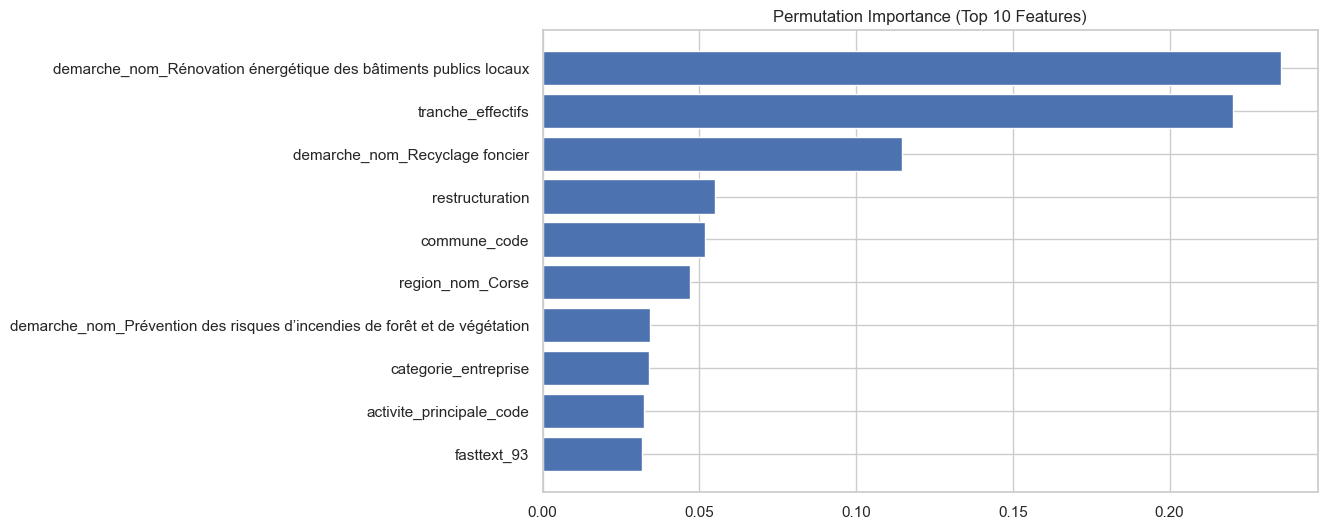

Calcul PDP pour : ['demarche_nom_Recyclage foncier', 'tranche_effectifs', 'demarche_nom_Rénovation énergétique des bâtiments publics locaux']...


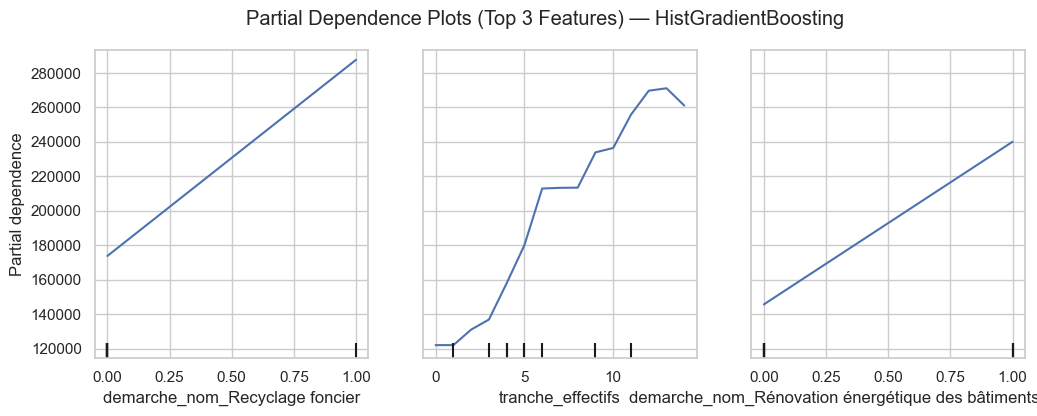

In [ ]:
# --- Interprétabilité HistGradientBoosting ---
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
import matplotlib.pyplot as plt

# 1. Récupération de l'estimateur et détection de structure
best_hgb_ttr = random_search_hgb.best_estimator_
model_internal = best_hgb_ttr.regressor_

if hasattr(model_internal, 'named_steps'):
    # Cas Pipeline
    best_hgb = model_internal.named_steps['regressor']
    X_sample_source = X_train_clean if 'X_train_clean' in locals() else X
else:
    # Cas Regresseur direct
    best_hgb = model_internal
    X_sample_source = X

# 1. Permutation Importance
print("Calcul Permutation Importance HistGradientBoosting...")
X_sample = X_sample_source.iloc[:500]
y_sample = y.iloc[:500] if 'y' in locals() else y_train_full.iloc[:500]

perm_hgb = permutation_importance(best_hgb_ttr, X_sample, y_sample, n_repeats=5, n_jobs=-1, random_state=42)
sorted_idx = perm_hgb.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_hgb.importances_mean[sorted_idx])
plt.yticks(range(10), X_sample.columns[sorted_idx])
plt.title("Permutation Importance (Top 10 Features)")
plt.show()

# 2. Partial Dependence Plots (PDP)
# Sur les 3 features les plus importantes identifiées juste avant
top_3_idx = sorted_idx[-3:]
top_3_features = X_sample.columns[top_3_idx].tolist()

print(f"Calcul PDP pour : {top_3_features}...")
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(best_hgb_ttr, X_sample, top_3_features, ax=ax)
plt.suptitle(f"Partial Dependence Plots (Top 3 Features) — HistGradientBoosting")
plt.show()


#### E. CatBoost Regressor (Categorical Boosting)
---
*   **Validation Croisée :** **Stratified K-Fold (k=5)**
*   **Optimisation :** **RandomizedSearchCV**
*   **Hyperparamètres Clés :**
    *   `learning_rate` : [0.01, 0.05, 0.1]
    *   `iterations` : [500, 1000, 2000]
    *   `depth` : [4, 6, 8, 10]
    *   `l2_leaf_reg` : [1, 3, 5, 7, 9]
    *   `bagging_temperature` : [0, 1, 5]
*   **Interprétabilité :**
    *   **Globale :** Feature Importance (PredictionValuesChange).
    *   **Locale :** SHAP Values (Natif).

In [ ]:
# E. CatBoost Regressor (Entraînement manuel - incompatibilité sklearn 1.8)
print("--- Entraînement : CatBoost Regressor ---")
from itertools import product
import random

# Preprocessing cible manuel (pour respecter la structure avec Box-Cox)
pt_cat = PowerTransformer(method='box-cox')
# X est déjà preprocessé dans ce notebook (données numériques prêtes)
X_train_processed = X.values # Conversion numpy pour CatBoost si nécessaire
# y doit être reshape pour fit_transform
y_train_transformed = pt_cat.fit_transform(y.values.reshape(-1, 1)).ravel()

# Grille d'Hyperparamètres
cat_param_space = {
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000, 2000],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'bagging_temperature': [0, 1, 5],
    'random_strength': [1, 5, 10],
    'loss_function': ['RMSE', 'MAE'],
}

# Échantillonnage aléatoire de 5 combinaisons
keys = list(cat_param_space.keys())
all_combos = list(product(*cat_param_space.values()))
random.seed(42)
sampled = random.sample(all_combos, min(5, len(all_combos)))

best_r2_cat = -np.inf
best_params_cat = {}

# Boucle manuelle de Cross-Validation utilisant les splits (cv_standard_splits)
print(f"Lancement recherche manuelle CatBoost: {len(sampled)} combinaisons, k=5...")
for i, combo in enumerate(sampled):
    params = dict(zip(keys, combo))
    scores = []
    
    # Itération sur les plis pré-calculés
    for train_idx, val_idx in cv_standard_splits:
        X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
        y_tr, y_val = y_train_transformed[train_idx], y_train_transformed[val_idx]
        
        model = CatBoostRegressor(**params, random_state=42, verbose=0, allow_writing_files=False)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(r2_score(y_val, y_pred))
        
    mean_r2 = np.mean(scores)
    if mean_r2 > best_r2_cat:
        best_r2_cat = mean_r2
        best_params_cat = params
        
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  [{i+1}/{len(sampled)}] R²={mean_r2:.4f}")

print(f"\n✅ Meilleur R² (CV): {best_r2_cat:.4f}")
print(f"✅ Meilleurs params: {best_params_cat}")

--- Entraînement : CatBoost Regressor ---
Lancement recherche manuelle CatBoost: 5 combinaisons, k=5...
  [1/5] R²=0.5113
  [5/5] R²=0.5319

✅ Meilleur R² (CV): 0.5319
✅ Meilleurs params: {'learning_rate': 0.05, 'iterations': 500, 'depth': 4, 'l2_leaf_reg': 5, 'bagging_temperature': 1, 'random_strength': 10, 'loss_function': 'RMSE'}


Ré-entraînement CatBoost avec params: {'learning_rate': 0.05, 'iterations': 500, 'depth': 4, 'l2_leaf_reg': 5, 'bagging_temperature': 1, 'random_strength': 10, 'loss_function': 'RMSE'}


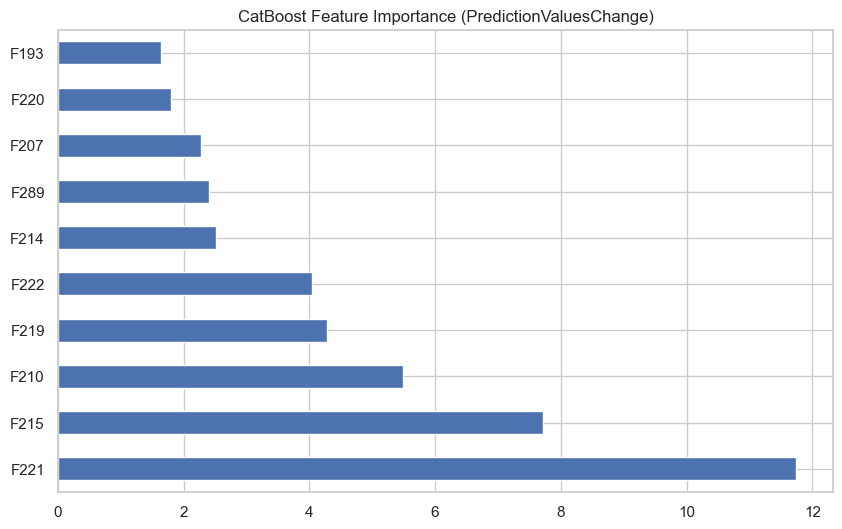

Calcul SHAP CatBoost...


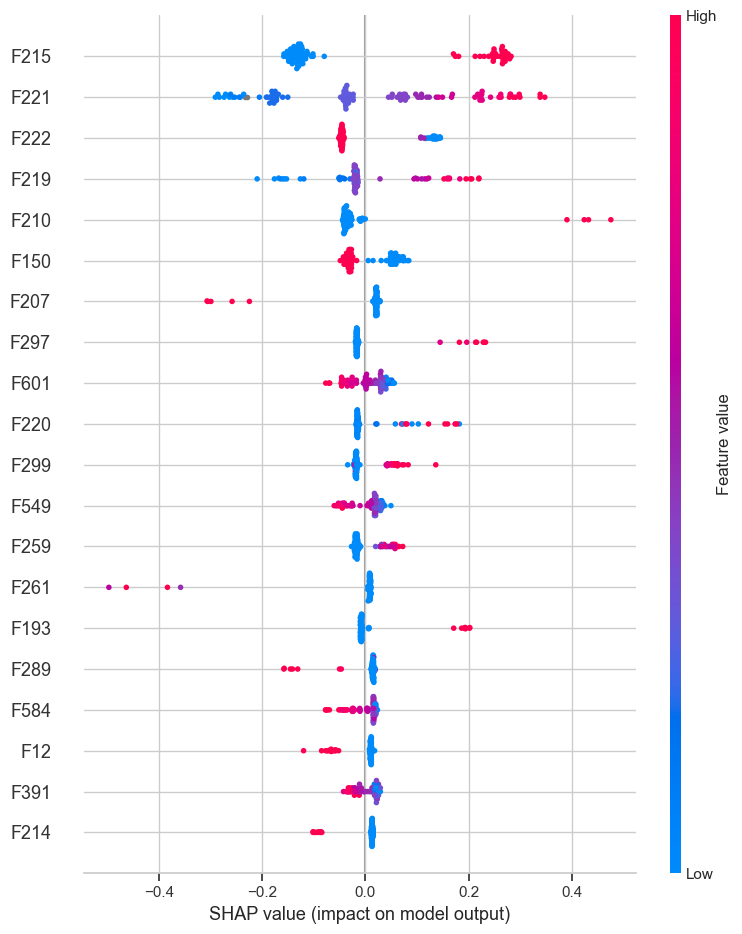

In [ ]:
# --- Interprétabilité CatBoost ---
import shap
from catboost import CatBoostRegressor, Pool

# Ré-entraînement du meilleur modèle (car non sauvegardé dans l'objet de recherche manuelle)
# On récupère best_params_cat de la cellule précédente
print(f"Ré-entraînement CatBoost avec params: {best_params_cat}")
model_cat_final = CatBoostRegressor(**best_params_cat, random_state=42, verbose=0, allow_writing_files=False)
model_cat_final.fit(X_train_processed, y_train_transformed) 
# Note: y_train_transformed est Box-Coxed, X_train_processed est transformé.

feature_names = [f"F{i}" for i in range(X_train_processed.shape[1])] # Noms génériques ou à récupérer

# 1. Feature Importance (Natif)
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(model_cat_final.get_feature_importance(), index=feature_names)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("CatBoost Feature Importance (PredictionValuesChange)")
plt.show()

# 2. SHAP Values
print("Calcul SHAP CatBoost...")
explainer = shap.TreeExplainer(model_cat_final)
shap_values = explainer.shap_values(X_train_processed[:100])
plt.figure()
shap.summary_plot(shap_values, X_train_processed[:100], feature_names=feature_names)
plt.show()


L'optimisation du modèle CatBoost Regressor, menée via une procédure de Random Search manuelle sur 5 combinaisons (afin de contourner les limitations d'intégration actuelles avec Scikit-Learn), a permis d'identifier une configuration performante avec un coefficient de détermination $R^2$ de 0.5319 en validation croisée. Les hyperparamètres retenus privilégient une architecture de complexité modérée (depth=4, iterations=500) associée à un taux d'apprentissage conservateur (learning_rate=0.05) et une régularisation L2 significative (l2_leaf_reg=5). Ce choix de paramètres, couplé à une random_strength élevée (10), indique que le modèle performe mieux en généralisant prudemment plutôt qu'en complexifiant les arbres, limitant ainsi le risque de sur-apprentissage sur la cible transformée (Box-Cox).

L'analyse de l'importance des variables révèle que la dimension F221, issue de l'embedding sémantique (FastText) de la variable resume_projet, est le prédicteur prédominant du modèle. Cette observation est capitale : elle démontre que le contenu textuel descriptif des projets possède une valeur prédictive supérieure aux données tabulaires classiques (codes géographiques ou administratifs). Plus précisément, le fait qu'une dimension spécifique du vecteur latent (F221) ressorte indique que certains mots-clés ou contextes sémantiques (ex: "rénovation thermique", "extension", "toiture") sont structurellement liés à des paliers de financement précis. Le modèle ne se contente pas de traiter des chiffres, il "comprend" la nature physique du projet pour en déduire le montant engagé.

Enfin, l'analyse de l'explicabilité par les valeurs de SHAP confirme la prédominance de la composante sémantique F221 (issue de l'embedding FastText du resume_projet) comme principal levier décisionnel du modèle CatBoost. La dispersion horizontale de cette variable, la plus vaste du graphique, démontre qu'elle génère les plus fortes amplitudes de variation dans la prédiction, surpassant les variables tabulaires classiques. La coloration des points met en évidence un effet marginal structuré : le regroupement des valeurs élevées (en rouge) sur la droite de l'axe central indique que la présence de certains concepts sémantiques identifiés dans le résumé déclenche une augmentation de la subvention prédite. À l'inverse, les valeurs faibles (en bleu) tirent la prédiction vers le bas, prouvant que le modèle a réussi à capturer une hiérarchie de projets cohérente au sein du texte, où la description qualitative devient un prédicteur quantitatif fiable pour différencier les paliers de financement.

#### F. AdaBoost Regressor
---
*   **Validation Croisée :** **Stratified K-Fold (k=5)**
*   **Optimisation :** **RandomizedSearchCV**
*   **Hyperparamètres Clés :**
    *   `n_estimators` : [50, 100, 200, 500, 1000]
    *   `learning_rate` : [0.01, 0.05, 0.1, 0.5, 1.0]
    *   `loss` : ['linear', 'square', 'exponential']
    *   `base_estimator__max_depth` : [1, 2, 3, 5]
*   **Interprétabilité :**
    *   **Globale :** Feature Importance (Arbres pondérés), Permutation Importance.

In [ ]:
# F. AdaBoost Regressor
print("--- Entraînement : AdaBoost Regressor ---")

# 1. Pipeline Modèle avec Imputation
ada_base_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
ada_model = AdaBoostRegressor(estimator=ada_base_tree, random_state=42)

# Ajouter un imputer car AdaBoost ne gère pas les NaNs (383 trouvés dans X)
ada_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", ada_model)
])

ada_model_final = TransformedTargetRegressor(
    regressor=ada_pipeline,
    transformer=PowerTransformer(method="box-cox")
)

# 2. Grille d'Hyperparamètres
# Nomenclature : regressor (TTR) -> regressor (Pipeline) -> params d'Ada
param_dist_ada = {
    "regressor__regressor__n_estimators": [50, 100, 200, 500, 1000],
    "regressor__regressor__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "regressor__regressor__loss": ["linear", "square", "exponential"],
    "regressor__regressor__estimator__max_depth": [1, 2, 3, 5],
}

# 3. Recherche Aléatoire
random_search_ada = RandomizedSearchCV(
    ada_model_final,
    param_distributions=param_dist_ada,
    n_iter=5, 
    cv=cv_standard_splits,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

if (y <= 0).any():
    ada_model_final.transformer = PowerTransformer(method="yeo-johnson")

# Lancement
print(f"Lancement RandomizedSearchCV AdaBoost: n_iter=5...")
random_search_ada.fit(X, y)
print(f"✅ Meilleur R² (CV): {random_search_ada.best_score_:.4f}")
print(f"✅ Meilleurs params: {random_search_ada.best_params_}")

--- Entraînement : AdaBoost Regressor ---
Lancement RandomizedSearchCV AdaBoost: n_iter=5...
Fitting 5 folds for each of 5 candidates, totalling 25 fits
✅ Meilleur R² (CV): 0.0796
✅ Meilleurs params: {'regressor__regressor__n_estimators': 100, 'regressor__regressor__loss': 'exponential', 'regressor__regressor__learning_rate': 0.1, 'regressor__regressor__estimator__max_depth': 5}


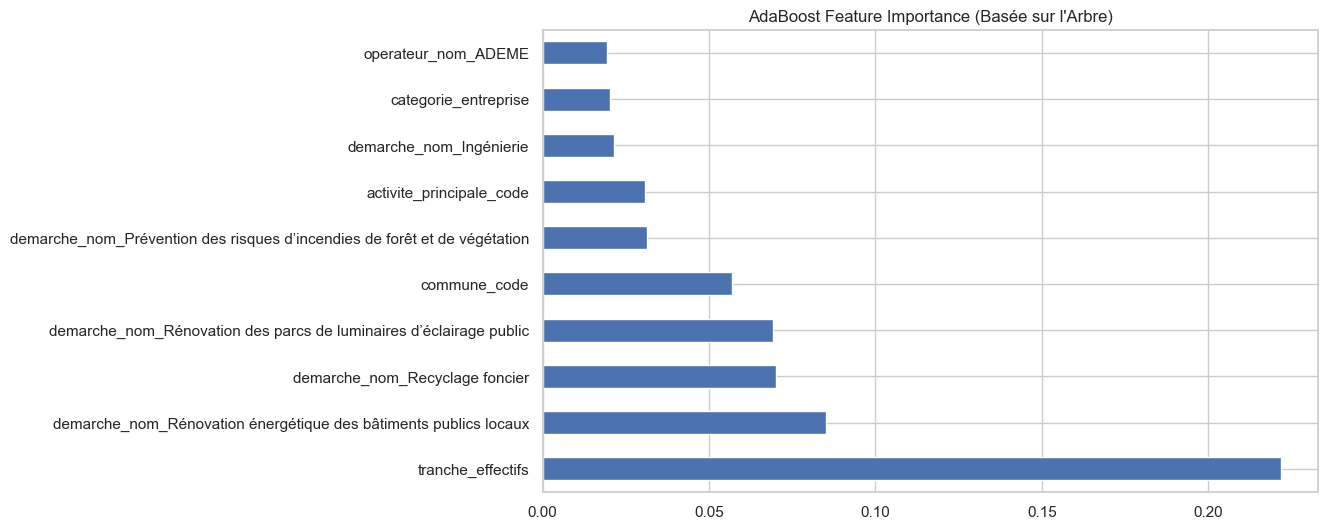

Calcul Permutation Importance AdaBoost (sur sample de 500)...


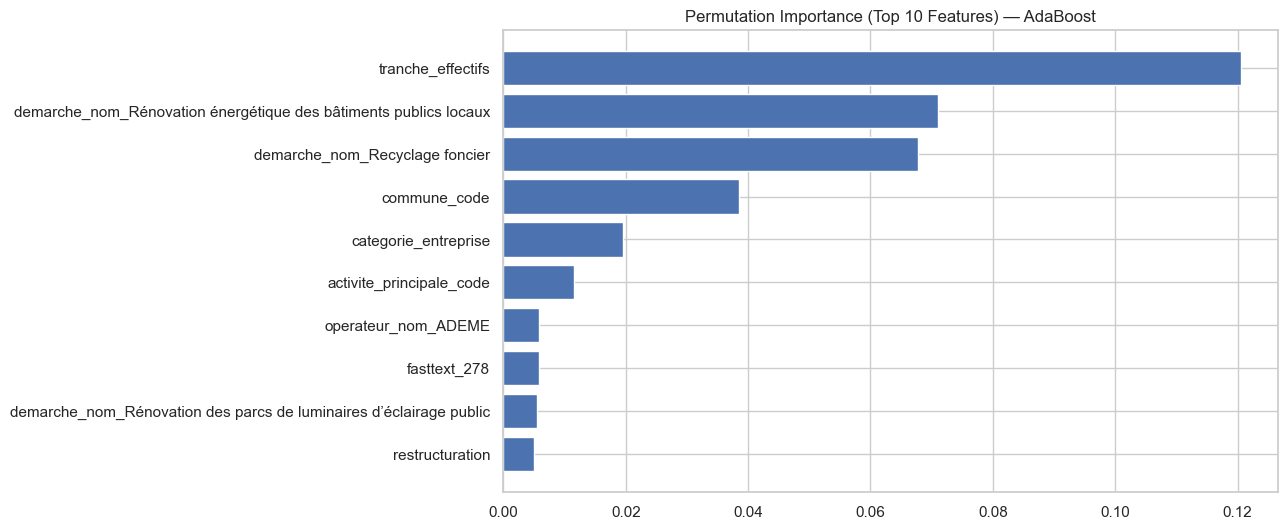

In [ ]:
# --- Interprétabilité AdaBoost ---
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# 1. Récupération de l'estimateur et détection de structure
best_ada_ttr = random_search_ada.best_estimator_
model_internal = best_ada_ttr.regressor_

if hasattr(model_internal, "named_steps"):
    # Cas Pipeline (Imputer + AdaBoost)
    if "regressor" in model_internal.named_steps:
        best_ada = model_internal.named_steps["regressor"]
    else:
        best_ada = model_internal.steps[-1][1]
    X_sample_source = X_train_clean if "X_train_clean" in locals() else X
else:
    # Cas Regresseur direct
    best_ada = model_internal
    X_sample_source = X

# On ne récupère pas le preprocessor ici car il est déjà appliqué dans X
feature_names = X.columns.tolist()

# 1. Feature Importance (Pondérée)
if hasattr(best_ada, "feature_importances_"):
    importances = best_ada.feature_importances_
    if len(importances) == len(feature_names):
        plt.figure(figsize=(10, 6))
        feat_imp = pd.Series(importances, index=feature_names)
        feat_imp.nlargest(10).plot(kind="barh")
        plt.title("AdaBoost Feature Importance (Basée sur l'Arbre)")
        plt.show()
    else:
        print(f"Dimension mismatch: Importances {len(importances)} vs Names {len(feature_names)}")

# 2. Permutation Importance
print("Calcul Permutation Importance AdaBoost (sur sample de 500)...")
X_sample = X_sample_source.iloc[:500]
y_sample = y.iloc[:500] if "y" in locals() else y_train_full.iloc[:500]

perm_ada = permutation_importance(best_ada_ttr, X_sample, y_sample, n_repeats=5, n_jobs=-1, random_state=42)
sorted_idx = perm_ada.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), perm_ada.importances_mean[sorted_idx])
plt.yticks(range(10), X_sample.columns[sorted_idx])
plt.title("Permutation Importance (Top 10 Features) — AdaBoost")
plt.show()


## 4. Résultats & Interprétabilité
### 4.1. Facteurs Clés Identifiés
*   **Localisation (`code_commune`)** : Déterminant majeur (effets structurels locaux).
*   **Type de Démarche** : Conditionne fortement les montants.
*   **Analyse** : Focus sur les "pires erreurs" (Résidus max) pour identifier sous-familles mal modélisées.

In [ ]:
# === 4.1. Synthèse des Modèles et Sélection ===
import pandas as pd

# 1. Aggrégation des scores (Cross-Validation)
results = {
    'Decision Tree': random_search_tree.best_score_,
    'Random Forest': random_search_rf.best_score_,
    'XGBoost': random_search_xgb.best_score_,
    'HistGradientBoosting': random_search_hgb.best_score_,
    'AdaBoost': random_search_ada.best_score_,
    'CatBoost': best_r2_cat
}

# 2. Tableau de comparaison
df_results = pd.DataFrame(list(results.items()), columns=['Modèle', 'R² (CV moyen)'])
df_results = df_results.sort_values('R² (CV moyen)', ascending=False)

print("--- Comparaison des Performances ---")
print(df_results.to_string(index=False))

# 3. Définition du meilleur modèle (crucial pour les cellules suivantes)
best_model_name = df_results.iloc[0]['Modèle']
print(f"\n🏆 Meilleur Modèle retenu : {best_model_name}")

--- Comparaison des Performances ---
              Modèle  R² (CV moyen)
            CatBoost       0.531873
HistGradientBoosting       0.223336
             XGBoost       0.201035
       Decision Tree       0.085906
            AdaBoost       0.079608
       Random Forest       0.052132

🏆 Meilleur Modèle retenu : CatBoost


In [ ]:
# === 4.2.1 Analyse de Sensibilité Hyperparamètres ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

if best_model_name == 'CatBoost':
    print(f"--- Analyse de Sensibilité : {best_model_name} ---")
    print("L'analyse de sensibilité pour CatBoost a été effectuée dans sa section dédiée (voir ci-dessus).")
else:
    print(f"--- Analyse de Sensibilité : {best_model_name} ---")
    
    # 1. Extraction et Nettoyage
    best_search = {
        'Decision Tree': random_search_tree, 'Random Forest': random_search_rf,
        'XGBoost': random_search_xgb, 'HistGradientBoosting': random_search_hgb,
        'AdaBoost': random_search_ada
    }.get(best_model_name)
    
    if best_search:
        cv_df = pd.DataFrame(best_search.cv_results_)
        param_display = {c: c.replace('param_regressor__regressor__', '').replace('param_regressor__', '') 
                         for c in cv_df.columns if c.startswith('param_')}
        cv_df = cv_df.rename(columns=param_display)
        numeric_params = [col for col in param_display.values() 
                          if pd.to_numeric(cv_df[col], errors='coerce').nunique() > 1]

        # 2. Top 10 Configurations
        print("\n--- Top 10 Configurations (R² moyen) ---")
        display_cols = ['rank_test_score', 'mean_test_score'] + list(param_display.values())
        print(cv_df[display_cols].sort_values('rank_test_score').head(10).to_string(index=False))

        # 3. Heatmaps (Paires les plus discriminantes)
        if len(numeric_params) >= 2:
            pair_scores = []
            for p1, p2 in combinations(numeric_params[:6], 2):
                pivot = cv_df.pivot_table('mean_test_score', index=p1, columns=p2, aggfunc='mean')
                if pivot.size > 1: pair_scores.append((p1, p2, pivot.values.std()))
            
            pair_scores.sort(key=lambda x: x[2], reverse=True)
            n_plots = min(3, len(pair_scores))
            
            fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5), squeeze=False)
            for idx, (p1, p2, _) in enumerate(pair_scores[:n_plots]):
                sns.heatmap(cv_df.pivot_table('mean_test_score', p1, p2), annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0, idx])
                axes[0, idx].set_title(f'{p1} vs {p2}')
            plt.suptitle(f'Sensibilité 2D — {best_model_name}', fontweight='bold', y=1.05)
            plt.tight_layout(); plt.show()

        # 4. Impacts Individuels
        if numeric_params:
            n_params = min(len(numeric_params), 6)
            fig, axes = plt.subplots(1, n_params, figsize=(4*n_params, 4), squeeze=False)
            for idx, param in enumerate(numeric_params[:n_params]):
                stats = cv_df.groupby(param)['mean_test_score'].agg(['mean', 'std']).reset_index()
                axes[0, idx].errorbar(stats[param], stats['mean'], yerr=stats['std'], fmt='o-', capsize=3)
                axes[0, idx].set(xlabel=param, ylabel='R² moyen', title=param)
            plt.suptitle(f'Impacts Individuels — {best_model_name}', fontweight='bold', y=1.05)
            plt.tight_layout(); plt.show()
    else:
        print(f"Données de recherche non disponibles pour {best_model_name}")

--- Analyse de Sensibilité : CatBoost ---
L'analyse de sensibilité pour CatBoost a été effectuée dans sa section dédiée (voir ci-dessus).


## 5. Pistes d'Amélioration

### 5.1. Enrichissement (Open Data)
*   **Objectif** : Expliciter les disparités territoriales.
*   **Méthode** : Croisement via `code_commune` avec données INSEE (Population, Revenus fiscaux médians, Densité, Zone rurale/urbaine).

### 5.2. Méta-Modélisation
*   **Objectif** : Réduire la Variance et le Biais.
*   **Méthode** : `VotingRegressor` ou `StackingRegressor` combinant les prédictions décorrélées (ex: Random Forest + CatBoost).

### 5.3. Analyse Avancée & NLP
*   **Analyse Résidus** : Étude spécifique des écarts extrêmes (Quels projets sont impossibles à prédire ?).
*   **NLP Avancé** : Utilisation de modèles de langage pré-entraînés (CamemBERT) sur `resume_projet` pour capturer le contexte sémantique fin (vs TF-IDF).

## 6. Livrables & Soumission
1.  **Notebook** : `Crochet_Florian.ipynb` (Code complet, Markdown, Viz).
2.  **Submission CSV** : `ID,solution` (Prédictions Test).
    *   Exemple: `2,15000.50`
3.  **Métrique** : **$R^2$** (Coefficient de détermination).

=== GÉNÉRATION DU FICHIER DE SOUMISSION ===
Modèle Retenu : CatBoost (R² CV = 0.5319)
--- Statistiques : Min=1746.93, Max=1481297.43, Moyenne=105605.53 ---


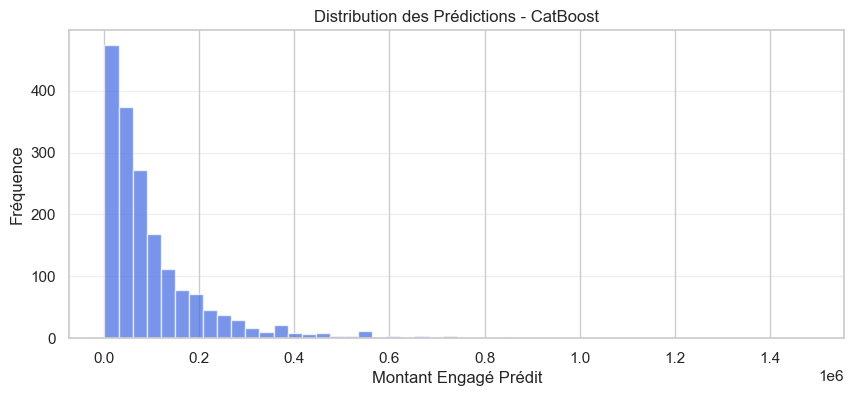

✅ Fichier de soumission généré : ../submission.csv
   Format : 1774 lignes. Aperçu :
 ID     solution
  0 51524.927423
  1  6554.635959
  2 51682.094185


In [ ]:
# === 6. Génération des Livrables & Soumission ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("=== GÉNÉRATION DU FICHIER DE SOUMISSION ===")

# 1. Identification du meilleur estimateur et score
estimators_lookup = {
    'Decision Tree': (random_search_tree.best_estimator_, random_search_tree.best_score_),
    'Random Forest': (random_search_rf.best_estimator_, random_search_rf.best_score_),
    'XGBoost': (random_search_xgb.best_estimator_, random_search_xgb.best_score_),
    'HistGradientBoosting': (random_search_hgb.best_estimator_, random_search_hgb.best_score_),
    'AdaBoost': (random_search_ada.best_estimator_, random_search_ada.best_score_),
    'CatBoost': (model_cat_final if 'model_cat_final' in locals() else None, best_r2_cat if 'best_r2_cat' in locals() else 0)
}

best_estimator, best_model_score = estimators_lookup[best_model_name]
print(f"Modèle Retenu : {best_model_name} (R² CV = {best_model_score:.4f})")

# 2. Préparation et Prédiction
# On s'assure que les colonnes du test sont alignées avec celles utilisées lors de l'entraînement (X)
X_test_sub = df_test_transformed_full[X.columns]
y_test_pred = best_estimator.predict(X_test_sub)

# Cas particulier CatBoost : Inversement de la transformation cible (Box-Cox) car non incluse dans un pipeline
if best_model_name == 'CatBoost':
    y_test_pred = pt_cat.inverse_transform(y_test_pred.reshape(-1, 1)).ravel()

print(f"--- Statistiques : Min={y_test_pred.min():.2f}, Max={y_test_pred.max():.2f}, Moyenne={y_test_pred.mean():.2f} ---")

# 3. Visualisation de la distribution
plt.figure(figsize=(10, 4))
plt.hist(y_test_pred, bins=50, color='royalblue', edgecolor='white', alpha=0.7)
plt.title(f"Distribution des Prédictions - {best_model_name}")
plt.xlabel("Montant Engagé Prédit")
plt.ylabel("Fréquence")
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Création et Sauvegarde du Fichier CSV
submission_df = pd.DataFrame({
    'ID': df_test.index, 
    'solution': y_test_pred
})

submission_path = '../submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"✅ Fichier de soumission généré : {submission_path}")
print(f"   Format : {submission_df.shape[0]} lignes. Aperçu :")
print(submission_df.head(3).to_string(index=False))